# 04_s5_diffusion_train_structured_v4

Structured and fully labelled Stream 5 training notebook.

This notebook keeps the same Stream 5 objective as before, but rebuilds the training notebook with clearer organisation and stronger diagnostics.

## What this version adds
- numbered markdown sections and labelled code cells
- fixed validation probe evaluated every epoch
- probe-dominant checkpoint selection
- jump-share penalty in training
- central-mass diagnostic to track the missing calm mass
- feasibility-filtered post-training calibration sweep
- multi-draw calibration ranking to reduce lucky single-sample selection
- richer plots and saved outputs

## Main outputs
- `s5_diffusion_config.json`
- `s5_diffusion_history.json`
- `s5_diffusion_best_total.pt`
- `s5_diffusion_best_probe.pt`
- `s5_diffusion_latest.pt`
- `s5_calibration_table.csv`
- `s5_calibration_best.json`
- plots in `s5_training_plots/`

## 1. Environment setup

This cell imports libraries, sets seeds, mounts Drive when running in Colab, and defines the fixed project paths.

In [1]:
# If needed in a fresh Colab runtime:
# %pip install -q pyarrow pandas numpy matplotlib scikit-learn

import copy
import json
import math
import random
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

try:
    from sklearn.metrics import average_precision_score, roc_auc_score
    SKLEARN_OK = True
except Exception:
    SKLEARN_OK = False

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    pass

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DATA_DIR = Path("/content/drive/MyDrive/energy_synthetic_data/data")

RETURNS_PATH = DATA_DIR / "returns_s5.parquet"
NORM_PATH = DATA_DIR / "norm_stats_s5.json"
COND_PATH = DATA_DIR / "conditioning_stats_s5.json"

OUT_CONFIG = DATA_DIR / "s5_diffusion_config.json"
OUT_HISTORY = DATA_DIR / "s5_diffusion_history.json"
OUT_BEST_TOTAL = DATA_DIR / "s5_diffusion_best_total.pt"
OUT_BEST_PROBE = DATA_DIR / "s5_diffusion_best_probe.pt"
OUT_LATEST = DATA_DIR / "s5_diffusion_latest.pt"
OUT_PROBE_JSON = DATA_DIR / "s5_validation_probe.json"

OUT_CALIB_CSV = DATA_DIR / "s5_calibration_table.csv"
OUT_CALIB_JSON = DATA_DIR / "s5_calibration_best.json"

CKPT_DIR = DATA_DIR / "s5_checkpoints"
PLOT_DIR = DATA_DIR / "s5_training_plots"
CKPT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

for p in [RETURNS_PATH, NORM_PATH, COND_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Missing required file: {p}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Mounted at /content/drive
Device: cuda


## 2. Stream 5 configuration

This cell holds the training, regularisation, probe, and calibration settings in one place.

In [2]:
@dataclass
class S5Config:
    # data / model
    seq_len: int = 72
    n_diffusion_steps: int = 128
    base_channels: int = 64
    dropout: float = 0.05

    # optimisation
    batch_size: int = 256
    num_workers: int = 2
    lr: float = 1e-4
    weight_decay: float = 1e-4
    warmup_epochs: int = 5
    max_epochs: int = 80
    min_epochs: int = 25
    patience: int = 20
    min_delta: float = 0.001
    grad_clip: float = 1.0
    ema_decay: float = 0.995
    denoise_target: str = "eps"  # "eps" or "v"

    # loss weights
    lambda_mask: float = 0.75
    lambda_jump: float = 1.00
    lambda_var: float = 0.10
    lambda_tail: float = 0.10
    lambda_haz: float = 0.10
    lambda_share: float = 0.25

    # diagnostics / thresholding
    tail_q: float = 0.95
    focal_gamma: float = 2.0
    jump_threshold: float = 0.50
    checkpoint_every: int = 5
    n_probe_rows: int = 256
    central_mass_tau: float = 0.20

    # calibration sweep
    calib_thresholds: tuple = (0.65, 0.70, 0.75, 0.80, 0.85, 0.90)
    calib_temperatures: tuple = (1.00, 1.20, 1.40)
    calib_jump_scales: tuple = (0.75, 0.85, 0.95, 1.00)

    # feasibility filter for calibration
    calib_min_recall: float = 0.05
    calib_min_pred_share_frac: float = 0.25
    calib_max_pred_share_mult: float = 3.00

    # use multiple stochastic samples in calibration ranking
    n_calib_draws: int = 3

CFG = S5Config()
print(CFG)

S5Config(seq_len=72, n_diffusion_steps=128, base_channels=64, dropout=0.05, batch_size=256, num_workers=2, lr=0.0001, weight_decay=0.0001, warmup_epochs=5, max_epochs=80, min_epochs=25, patience=20, min_delta=0.001, grad_clip=1.0, ema_decay=0.995, denoise_target='eps', lambda_mask=0.75, lambda_jump=1.0, lambda_var=0.1, lambda_tail=0.1, lambda_haz=0.1, lambda_share=0.25, tail_q=0.95, focal_gamma=2.0, jump_threshold=0.5, checkpoint_every=5, n_probe_rows=256, central_mass_tau=0.2, calib_thresholds=(0.65, 0.7, 0.75, 0.8, 0.85, 0.9), calib_temperatures=(1.0, 1.2, 1.4), calib_jump_scales=(0.75, 0.85, 0.95, 1.0), calib_min_recall=0.05, calib_min_pred_share_frac=0.25, calib_max_pred_share_mult=3.0, n_calib_draws=3)


## 3. Load the prepared Stream 5 data

This cell reads the prep artifacts, checks the schema, imputes any remaining conditioning NaNs from the train split, and creates the split DataFrames.

In [3]:
returns_s5 = pd.read_parquet(RETURNS_PATH).copy()
with open(NORM_PATH, "r") as f:
    norm_stats = json.load(f)
with open(COND_PATH, "r") as f:
    cond_stats = json.load(f)

r_cols = sorted([c for c in returns_s5.columns if c.startswith("r_")])
mask_cols = sorted([c for c in returns_s5.columns if c.startswith("jump_mask_")])
jump_cols = sorted([c for c in returns_s5.columns if c.startswith("jump_size_")])
cond_cols = sorted([c for c in returns_s5.columns if c.startswith("cond_")])

conditioning_dim = int(cond_stats["conditioning_dim"])

if len(r_cols) != CFG.seq_len:
    raise ValueError(f"Expected {CFG.seq_len} target columns, found {len(r_cols)}")
if len(mask_cols) != CFG.seq_len or len(jump_cols) != CFG.seq_len:
    raise ValueError("Jump mask / jump size column counts do not match seq_len")
if len(cond_cols) != conditioning_dim:
    raise ValueError(f"conditioning_stats says {conditioning_dim} dims, but found {len(cond_cols)} cond columns")
if "split" not in returns_s5.columns:
    raise KeyError("returns_s5.parquet must contain split")

print("returns_s5 shape:", returns_s5.shape)
print("Split counts:", returns_s5["split"].value_counts(dropna=False).to_dict())
print("Target kind:", norm_stats.get("target_kind"))
print("Conditioning dim:", conditioning_dim)

train_df = returns_s5.loc[returns_s5["split"].eq("train")].copy()
val_df = returns_s5.loc[returns_s5["split"].eq("val")].copy()
test_df = returns_s5.loc[returns_s5["split"].eq("test")].copy()

if len(train_df) == 0 or len(val_df) == 0:
    raise RuntimeError("Need non-empty train and val splits")

cond_train = train_df[cond_cols].apply(pd.to_numeric, errors="coerce")
cond_impute = cond_train.median(axis=0).fillna(0.0)

train_nonnull = cond_train.notna().sum()
dead_cond_cols = train_nonnull.index[train_nonnull.eq(0)].tolist()

print("\nTrain non-null counts for cond columns:")
print(train_nonnull.to_string())
print("Dead cond cols on train:", dead_cond_cols)

returns_s5[cond_cols] = (
    returns_s5[cond_cols]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(cond_impute)
)

for cols, name, fill_value in [
    (r_cols, "r", 0.0),
    (mask_cols, "jump_mask", 0.0),
    (jump_cols, "jump_size", 0.0),
]:
    arr = returns_s5[cols].apply(pd.to_numeric, errors="coerce")
    if arr.isna().any().any():
        print(f"Filling NaNs in {name} block with {fill_value}")
        returns_s5[cols] = arr.fillna(fill_value)

hazard_idx = list(range(conditioning_dim - 3, conditioning_dim))
print("Hazard cond indices:", hazard_idx)

returns_s5 shape: (6518, 241)
Split counts: {'train': 4568, 'test': 977, 'val': 973}
Target kind: asinh_diff
Conditioning dim: 19

Train non-null counts for cond columns:
cond_000    4568
cond_001    4568
cond_002    4568
cond_003    4567
cond_004    4567
cond_005    4568
cond_006    4557
cond_007    4568
cond_008    4568
cond_009    4568
cond_010    4568
cond_011    4568
cond_012    4568
cond_013    4568
cond_014    4568
cond_015    4568
cond_016    4568
cond_017    4568
cond_018    4568
Dead cond cols on train: []
Filling NaNs in r block with 0.0
Hazard cond indices: [16, 17, 18]


## 4. Dataset and DataLoader construction

This cell wraps the parquet into PyTorch datasets and loaders.

In [4]:
class ReturnsDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, r_cols, mask_cols, jump_cols, cond_cols, hazard_idx):
        self.x = frame[r_cols].to_numpy(np.float32)
        self.mask = frame[mask_cols].to_numpy(np.float32)
        self.jump = frame[jump_cols].to_numpy(np.float32)
        self.cond = frame[cond_cols].to_numpy(np.float32)
        self.haz = self.cond[:, hazard_idx].astype(np.float32)
        self.seg_id = frame["seg_id"].to_numpy(np.int64) if "seg_id" in frame.columns else np.arange(len(frame))
        self.start_idx = frame["start_idx"].to_numpy(np.int64) if "start_idx" in frame.columns else np.arange(len(frame))

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return {
            "x0": torch.from_numpy(self.x[idx]),
            "jump_mask": torch.from_numpy(self.mask[idx]),
            "jump_size": torch.from_numpy(self.jump[idx]),
            "cond": torch.from_numpy(self.cond[idx]),
            "haz": torch.from_numpy(self.haz[idx]),
            "seg_id": torch.tensor(self.seg_id[idx], dtype=torch.long),
            "start_idx": torch.tensor(self.start_idx[idx], dtype=torch.long),
        }

train_ds = ReturnsDataset(returns_s5.loc[returns_s5["split"].eq("train")].copy(), r_cols, mask_cols, jump_cols, cond_cols, hazard_idx)
val_ds = ReturnsDataset(returns_s5.loc[returns_s5["split"].eq("val")].copy(), r_cols, mask_cols, jump_cols, cond_cols, hazard_idx)

train_loader = DataLoader(
    train_ds,
    batch_size=CFG.batch_size,
    shuffle=True,
    drop_last=False,
    num_workers=CFG.num_workers,
    pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
    val_ds,
    batch_size=CFG.batch_size,
    shuffle=False,
    drop_last=False,
    num_workers=CFG.num_workers,
    pin_memory=torch.cuda.is_available(),
)

print("n_train:", len(train_ds), "n_val:", len(val_ds))
print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))

n_train: 4568 n_val: 973
Train batches: 18
Val batches  : 4


## 5. Diffusion scheduler

This cell defines the forward noising process and the helper formulas used for training and sampling.

In [5]:
def make_beta_schedule(n_steps: int, start: float = 1e-4, end: float = 2e-2):
    return torch.linspace(start, end, n_steps, dtype=torch.float32)

class DiffusionScheduler:
    def __init__(self, n_steps: int, device: torch.device):
        betas = make_beta_schedule(n_steps).to(device)
        alphas = 1.0 - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)
        alphas_cumprod_prev = torch.cat([torch.ones(1, device=device), alphas_cumprod[:-1]], dim=0)

        self.n_steps = n_steps
        self.betas = betas
        self.alphas = alphas
        self.alphas_cumprod = alphas_cumprod
        self.alphas_cumprod_prev = alphas_cumprod_prev
        self.sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)
        self.sqrt_recip_alphas_cumprod = torch.sqrt(1.0 / alphas_cumprod)
        self.sqrt_recipm1_alphas_cumprod = torch.sqrt(1.0 / alphas_cumprod - 1.0)

        self.posterior_variance = (
            betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)
        ).clamp(min=1e-20)
        self.posterior_mean_coef1 = (
            betas * torch.sqrt(alphas_cumprod_prev) / (1.0 - alphas_cumprod)
        )
        self.posterior_mean_coef2 = (
            (1.0 - alphas_cumprod_prev) * torch.sqrt(alphas) / (1.0 - alphas_cumprod)
        )

    def _extract(self, a: torch.Tensor, t: torch.Tensor, x_shape):
        out = a.gather(0, t)
        return out.view(-1, *([1] * (len(x_shape) - 1)))

    def q_sample(self, x0: torch.Tensor, t: torch.Tensor, noise: torch.Tensor):
        return (
            self._extract(self.sqrt_alphas_cumprod, t, x0.shape) * x0
            + self._extract(self.sqrt_one_minus_alphas_cumprod, t, x0.shape) * noise
        )

    def predict_v(self, x0: torch.Tensor, noise: torch.Tensor, t: torch.Tensor):
        return (
            self._extract(self.sqrt_alphas_cumprod, t, x0.shape) * noise
            - self._extract(self.sqrt_one_minus_alphas_cumprod, t, x0.shape) * x0
        )

    def predict_x0_from_eps(self, xt: torch.Tensor, t: torch.Tensor, eps: torch.Tensor):
        return (
            self._extract(self.sqrt_recip_alphas_cumprod, t, xt.shape) * xt
            - self._extract(self.sqrt_recipm1_alphas_cumprod, t, xt.shape) * eps
        )

    def predict_x0_from_v(self, xt: torch.Tensor, t: torch.Tensor, v: torch.Tensor):
        sqrt_acp = self._extract(self.sqrt_alphas_cumprod, t, xt.shape)
        sqrt_om = self._extract(self.sqrt_one_minus_alphas_cumprod, t, xt.shape)
        return sqrt_acp * xt - sqrt_om * v

scheduler = DiffusionScheduler(CFG.n_diffusion_steps, device)

## 6. Model blocks

This cell defines the timestep embedding, conditioning projector, residual blocks, and the jump-aware 1D U-Net.

In [6]:
def timestep_embedding(timesteps: torch.Tensor, dim: int, max_period: int = 10000):
    half = dim // 2
    freqs = torch.exp(
        -math.log(max_period) * torch.arange(0, half, dtype=torch.float32, device=timesteps.device) / max(half, 1)
    )
    args = timesteps.float().unsqueeze(1) * freqs.unsqueeze(0)
    emb = torch.cat([torch.cos(args), torch.sin(args)], dim=1)
    if dim % 2:
        emb = torch.cat([emb, torch.zeros_like(emb[:, :1])], dim=1)
    return emb

class TimeEmbedding(nn.Module):
    def __init__(self, emb_dim: int):
        super().__init__()
        self.emb_dim = emb_dim
        self.net = nn.Sequential(
            nn.Linear(emb_dim, emb_dim * 4),
            nn.SiLU(),
            nn.Linear(emb_dim * 4, emb_dim),
        )

    def forward(self, t: torch.Tensor):
        return self.net(timestep_embedding(t, self.emb_dim))

class ConditionProjector(nn.Module):
    def __init__(self, cond_dim: int, emb_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(cond_dim, emb_dim * 2),
            nn.SiLU(),
            nn.Linear(emb_dim * 2, emb_dim),
        )

    def forward(self, cond: torch.Tensor):
        return self.net(cond)

class ResidualBlock1D(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, emb_dim: int, dropout: float):
        super().__init__()
        self.norm1 = nn.GroupNorm(num_groups=min(8, in_ch), num_channels=in_ch)
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size=3, padding=1)

        self.norm2 = nn.GroupNorm(num_groups=min(8, out_ch), num_channels=out_ch)
        self.dropout = nn.Dropout(dropout)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size=3, padding=1)

        # FiLM is applied to the pre-conv channels.
        self.emb_proj = nn.Linear(emb_dim, in_ch * 2)
        self.skip = nn.Conv1d(in_ch, out_ch, kernel_size=1) if in_ch != out_ch else nn.Identity()

    def forward(self, x: torch.Tensor, emb: torch.Tensor):
        h = self.norm1(x)
        scale, shift = self.emb_proj(emb).chunk(2, dim=1)
        h = h * (1.0 + scale.unsqueeze(-1)) + shift.unsqueeze(-1)
        h = F.silu(h)
        h = self.conv1(h)

        h = self.norm2(h)
        h = F.silu(h)
        h = self.dropout(h)
        h = self.conv2(h)
        return h + self.skip(x)

class Downsample1D(nn.Module):
    def __init__(self, ch: int):
        super().__init__()
        self.op = nn.Conv1d(ch, ch, kernel_size=4, stride=2, padding=1)

    def forward(self, x):
        return self.op(x)

class Upsample1D(nn.Module):
    def __init__(self, ch: int):
        super().__init__()
        self.op = nn.ConvTranspose1d(ch, ch, kernel_size=4, stride=2, padding=1)

    def forward(self, x):
        return self.op(x)

class JumpAwareUNet1D(nn.Module):
    def __init__(self, seq_len: int, cond_dim: int, base_channels: int, dropout: float):
        super().__init__()
        emb_dim = base_channels * 4
        self.seq_len = seq_len
        self.time_emb = TimeEmbedding(emb_dim)
        self.cond_emb = ConditionProjector(cond_dim, emb_dim)

        self.in_proj = nn.Conv1d(1, base_channels, kernel_size=3, padding=1)

        self.down1 = ResidualBlock1D(base_channels, base_channels, emb_dim, dropout)
        self.ds1 = Downsample1D(base_channels)

        self.down2 = ResidualBlock1D(base_channels, base_channels * 2, emb_dim, dropout)
        self.ds2 = Downsample1D(base_channels * 2)

        self.mid = ResidualBlock1D(base_channels * 2, base_channels * 4, emb_dim, dropout)

        self.us2 = Upsample1D(base_channels * 4)
        self.up2 = ResidualBlock1D(base_channels * 4 + base_channels * 2, base_channels * 2, emb_dim, dropout)

        self.us1 = Upsample1D(base_channels * 2)
        self.up1 = ResidualBlock1D(base_channels * 2 + base_channels, base_channels, emb_dim, dropout)

        self.out_norm = nn.GroupNorm(num_groups=min(8, base_channels), num_channels=base_channels)
        self.eps_head = nn.Conv1d(base_channels, 1, kernel_size=1)
        self.mask_head = nn.Conv1d(base_channels, 1, kernel_size=1)
        self.jump_head = nn.Conv1d(base_channels, 1, kernel_size=1)

    def forward(self, xt: torch.Tensor, t: torch.Tensor, cond: torch.Tensor):
        x = xt.unsqueeze(1)
        emb = self.time_emb(t) + self.cond_emb(cond)

        x0 = self.in_proj(x)
        d1 = self.down1(x0, emb)
        h = self.ds1(d1)

        d2 = self.down2(h, emb)
        h = self.ds2(d2)

        h = self.mid(h, emb)

        h = self.us2(h)
        if h.shape[-1] != d2.shape[-1]:
            h = F.interpolate(h, size=d2.shape[-1], mode="nearest")
        h = torch.cat([h, d2], dim=1)
        h = self.up2(h, emb)

        h = self.us1(h)
        if h.shape[-1] != d1.shape[-1]:
            h = F.interpolate(h, size=d1.shape[-1], mode="nearest")
        h = torch.cat([h, d1], dim=1)
        h = self.up1(h, emb)

        h = self.out_norm(h)
        h = F.silu(h)

        eps = self.eps_head(h).squeeze(1)
        mask_logits = self.mask_head(h).squeeze(1)

        # Suppress the jump head at very high noise levels.
        gate_scale = (1.0 - t.float() / max(1, scheduler.n_steps - 1)).unsqueeze(1)
        jump = self.jump_head(h).squeeze(1) * gate_scale
        return eps, mask_logits, jump

model = JumpAwareUNet1D(
    seq_len=CFG.seq_len,
    cond_dim=conditioning_dim,
    base_channels=CFG.base_channels,
    dropout=CFG.dropout,
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {n_params:,}")

Model parameters: 2,251,715


## 7. Optimiser, LR schedule, AMP, and EMA

This cell creates the optimiser, learning-rate schedule, mixed-precision scaler, and EMA wrapper.

In [7]:
optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)

def lr_lambda(epoch_idx: int):
    e = epoch_idx + 1
    if e <= CFG.warmup_epochs:
        return e / max(CFG.warmup_epochs, 1)
    progress = (e - CFG.warmup_epochs) / max(CFG.max_epochs - CFG.warmup_epochs, 1)
    progress = min(max(progress, 0.0), 1.0)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler_lr = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)
scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())

class EMA:
    def __init__(self, model: nn.Module, decay: float):
        self.decay = decay
        self.shadow = {k: v.detach().clone() for k, v in model.state_dict().items()}

    @torch.no_grad()
    def update(self, model: nn.Module):
        for k, v in model.state_dict().items():
            self.shadow[k].mul_(self.decay).add_(v.detach(), alpha=1.0 - self.decay)

    @torch.no_grad()
    def copy_to(self, model: nn.Module):
        model.load_state_dict(self.shadow, strict=True)

ema = EMA(model, CFG.ema_decay)

## 8. Loss helpers and evaluation helpers

This cell defines the focal loss, tail gap, share gap, and the training / validation loss computation.

In [8]:
pos_frac = float(returns_s5.loc[returns_s5["split"].eq("train"), mask_cols].to_numpy().mean())
pos_weight_val = (1.0 - pos_frac) / max(pos_frac, 1e-6)
pos_weight = torch.tensor(pos_weight_val, dtype=torch.float32, device=device)
print("Train jump positive share:", pos_frac)
print("Mask pos_weight:", float(pos_weight.item()))

def focal_bce_with_logits(logits: torch.Tensor, targets: torch.Tensor, pos_weight: torch.Tensor, gamma: float):
    bce = F.binary_cross_entropy_with_logits(logits, targets, pos_weight=pos_weight, reduction="none")
    probs = torch.sigmoid(logits)
    pt = torch.where(targets > 0.5, probs, 1.0 - probs)
    mod = (1.0 - pt).pow(gamma)
    return (mod * bce).mean()

def tail_gap(x_hat: torch.Tensor, x_true: torch.Tensor, q: float):
    q_hat = torch.quantile(x_hat.abs().reshape(-1), q)
    q_true = torch.quantile(x_true.abs().reshape(-1), q)
    return (q_hat - q_true).abs()

def share_gap(mask_logits: torch.Tensor, targets: torch.Tensor):
    pred_share = torch.sigmoid(mask_logits).mean()
    true_share = targets.mean()
    return (pred_share - true_share).abs()

def summarise_binary_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(np.int64)
    y_prob = np.asarray(y_prob).astype(np.float64)
    y_pred = (y_prob >= threshold).astype(np.int64)

    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())
    tn = int(((y_pred == 0) & (y_true == 0)).sum())

    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)
    acc = (tp + tn) / max(tp + tn + fp + fn, 1)

    out = {
        "jump_precision": float(precision),
        "jump_recall": float(recall),
        "jump_f1": float(f1),
        "jump_acc": float(acc),
    }

    if SKLEARN_OK:
        try:
            if len(np.unique(y_true)) > 1:
                out["jump_auroc"] = float(roc_auc_score(y_true, y_prob))
                out["jump_ap"] = float(average_precision_score(y_true, y_prob))
            else:
                out["jump_auroc"] = float("nan")
                out["jump_ap"] = float("nan")
        except Exception:
            out["jump_auroc"] = float("nan")
            out["jump_ap"] = float("nan")
    else:
        out["jump_auroc"] = float("nan")
        out["jump_ap"] = float("nan")
    return out

def compute_losses(batch):
    x0 = batch["x0"].to(device, non_blocking=True)
    jump_mask = batch["jump_mask"].to(device, non_blocking=True)
    jump_size = batch["jump_size"].to(device, non_blocking=True)
    cond = batch["cond"].to(device, non_blocking=True)
    haz = batch["haz"].to(device, non_blocking=True)

    bsz = x0.shape[0]
    t = torch.randint(0, scheduler.n_steps, (bsz,), device=device)
    noise = torch.randn_like(x0)
    xt = scheduler.q_sample(x0, t, noise)

    pred_eps, mask_logits, jump_pred = model(xt, t, cond)

    if CFG.denoise_target == "eps":
        denoise_target = noise
        diff_loss = F.mse_loss(pred_eps, denoise_target)
        x0_hat = scheduler.predict_x0_from_eps(xt, t, pred_eps)
    else:
        denoise_target = scheduler.predict_v(x0, noise, t)
        diff_loss = F.mse_loss(pred_eps, denoise_target)
        x0_hat = scheduler.predict_x0_from_v(xt, t, pred_eps)

    mask_loss = focal_bce_with_logits(mask_logits, jump_mask, pos_weight, CFG.focal_gamma)

    if jump_mask.sum() > 0:
        jump_loss = F.huber_loss(jump_pred[jump_mask > 0.5], jump_size[jump_mask > 0.5], delta=1.0)
    else:
        jump_loss = torch.tensor(0.0, device=device)

    var_loss = F.mse_loss(x0_hat.std(dim=1), x0.std(dim=1))
    tail_loss = tail_gap(x0_hat, x0, CFG.tail_q)

    gate_rate = torch.sigmoid(mask_logits).mean(dim=1)
    hazard_target = torch.sigmoid(haz.max(dim=1).values)
    haz_loss = F.mse_loss(gate_rate, hazard_target)

    pred_share_batch = torch.sigmoid(mask_logits).mean()
    true_share_batch = jump_mask.float().mean()
    share_loss = torch.abs(pred_share_batch - true_share_batch)

    total = (
        diff_loss
        + CFG.lambda_mask * mask_loss
        + CFG.lambda_jump * jump_loss
        + CFG.lambda_var * var_loss
        + CFG.lambda_tail * tail_loss
        + CFG.lambda_haz * haz_loss
        + CFG.lambda_share * share_loss
    )

    with torch.no_grad():
        std_gap = (x0_hat.std(dim=1) - x0.std(dim=1)).abs().mean()
        tail_gap_proxy = tail_gap(x0_hat, x0, CFG.tail_q)
        pred_jump_prob = torch.sigmoid(mask_logits)
        pred_jump_share = (pred_jump_prob >= CFG.jump_threshold).float().mean()
        true_jump_share = jump_mask.mean()
        jump_mae = (jump_pred[jump_mask > 0.5] - jump_size[jump_mask > 0.5]).abs().mean() if jump_mask.sum() > 0 else torch.tensor(0.0, device=device)

    metrics = {
        "loss_total": float(total.detach().cpu()),
        "loss_diff": float(diff_loss.detach().cpu()),
        "loss_mask": float(mask_loss.detach().cpu()),
        "loss_jump": float(jump_loss.detach().cpu()),
        "loss_var": float(var_loss.detach().cpu()),
        "loss_tail": float(tail_loss.detach().cpu()),
        "loss_haz": float(haz_loss.detach().cpu()),
        "loss_share": float(share_loss.detach().cpu()),
        "std_gap_proxy": float(std_gap.detach().cpu()),
        "tail_gap_proxy": float(tail_gap_proxy.detach().cpu()),
        "pred_jump_share": float(pred_jump_share.detach().cpu()),
        "true_jump_share": float(true_jump_share.detach().cpu()),
        "jump_mae_on_true": float(jump_mae.detach().cpu()),
    }

    extras = {
        "y_true": jump_mask.detach().cpu().numpy().reshape(-1),
        "y_prob": pred_jump_prob.detach().cpu().numpy().reshape(-1),
    }
    return total, metrics, extras

@torch.no_grad()
def evaluate(model_for_eval: nn.Module, loader: DataLoader):
    model_for_eval.eval()
    sums = {}
    n_batches = 0
    all_y_true = []
    all_y_prob = []

    for batch in loader:
        x0 = batch["x0"].to(device, non_blocking=True)
        jump_mask = batch["jump_mask"].to(device, non_blocking=True)
        jump_size = batch["jump_size"].to(device, non_blocking=True)
        cond = batch["cond"].to(device, non_blocking=True)
        haz = batch["haz"].to(device, non_blocking=True)

        bsz = x0.shape[0]
        t = torch.randint(0, scheduler.n_steps, (bsz,), device=device)
        noise = torch.randn_like(x0)
        xt = scheduler.q_sample(x0, t, noise)

        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            pred_eps, mask_logits, jump_pred = model_for_eval(xt, t, cond)

            if CFG.denoise_target == "eps":
                denoise_target = noise
                diff_loss = F.mse_loss(pred_eps, denoise_target)
                x0_hat = scheduler.predict_x0_from_eps(xt, t, pred_eps)
            else:
                denoise_target = scheduler.predict_v(x0, noise, t)
                diff_loss = F.mse_loss(pred_eps, denoise_target)
                x0_hat = scheduler.predict_x0_from_v(xt, t, pred_eps)

            mask_loss = focal_bce_with_logits(mask_logits, jump_mask, pos_weight, CFG.focal_gamma)
            if jump_mask.sum() > 0:
                jump_loss = F.huber_loss(jump_pred[jump_mask > 0.5], jump_size[jump_mask > 0.5], delta=1.0)
                jump_mae = (jump_pred[jump_mask > 0.5] - jump_size[jump_mask > 0.5]).abs().mean()
            else:
                jump_loss = torch.tensor(0.0, device=device)
                jump_mae = torch.tensor(0.0, device=device)

            var_loss = F.mse_loss(x0_hat.std(dim=1), x0.std(dim=1))
            tgap = tail_gap(x0_hat, x0, CFG.tail_q)
            gate_rate = torch.sigmoid(mask_logits).mean(dim=1)
            hazard_target = torch.sigmoid(haz.max(dim=1).values)
            haz_loss = F.mse_loss(gate_rate, hazard_target)
            share_loss = share_gap(mask_logits, jump_mask)

            total = (
                diff_loss
                + CFG.lambda_mask * mask_loss
                + CFG.lambda_jump * jump_loss
                + CFG.lambda_var * var_loss
                + CFG.lambda_tail * tgap
                + CFG.lambda_haz * haz_loss
                + CFG.lambda_share * share_loss
            )

        pred_prob = torch.sigmoid(mask_logits)
        batch_stats = {
            "loss_total": float(total.detach().cpu()),
            "loss_diff": float(diff_loss.detach().cpu()),
            "loss_mask": float(mask_loss.detach().cpu()),
            "loss_jump": float(jump_loss.detach().cpu()),
            "loss_var": float(var_loss.detach().cpu()),
            "loss_tail": float(tgap.detach().cpu()),
            "loss_haz": float(haz_loss.detach().cpu()),
            "loss_share": float(share_loss.detach().cpu()),
            "std_gap_proxy": float(((x0_hat.std(dim=1) - x0.std(dim=1)).abs().mean()).detach().cpu()),
            "tail_gap_proxy": float(tgap.detach().cpu()),
            "pred_jump_share": float(((pred_prob >= CFG.jump_threshold).float().mean()).detach().cpu()),
            "true_jump_share": float(jump_mask.mean().detach().cpu()),
            "jump_mae_on_true": float(jump_mae.detach().cpu()),
        }

        for k, v in batch_stats.items():
            sums[k] = sums.get(k, 0.0) + float(v)
        n_batches += 1
        all_y_true.append(jump_mask.detach().cpu().numpy().reshape(-1))
        all_y_prob.append(pred_prob.detach().cpu().numpy().reshape(-1))

    out = {k: v / max(n_batches, 1) for k, v in sums.items()}
    y_true = np.concatenate(all_y_true)
    y_prob = np.concatenate(all_y_prob)
    out.update(summarise_binary_metrics(y_true, y_prob, threshold=CFG.jump_threshold))

    # Logged for monitoring only; checkpoint selection is probe-dominant below.
    out["proxy_score"] = (
        out["loss_total"]
        + 0.25 * out["std_gap_proxy"]
        + 0.25 * out["tail_gap_proxy"]
        + 0.25 * abs(out["pred_jump_share"] - out["true_jump_share"])
        + 0.10 * (1.0 - out["jump_f1"])
    )
    return out

Train jump positive share: 0.06910391126678342
Mask pos_weight: 13.47096061706543


## 9. Sampling, fixed probe, and calibration helpers

This cell defines the reverse-diffusion sampler, constructs the fixed validation probe set, and adds the calibration and central-mass helpers.

In [9]:
@torch.no_grad()
def ddpm_sample(model_for_eval: nn.Module, cond: torch.Tensor, n_steps: int | None = None):
    model_for_eval.eval()
    n_steps = scheduler.n_steps if n_steps is None else n_steps
    x = torch.randn(cond.shape[0], CFG.seq_len, device=device)

    final_mask_prob = None
    final_jump = None

    for step in reversed(range(n_steps)):
        t = torch.full((cond.shape[0],), step, device=device, dtype=torch.long)
        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            pred_eps, mask_logits, jump_pred = model_for_eval(x, t, cond)

        x0_hat = scheduler.predict_x0_from_eps(x, t, pred_eps) if CFG.denoise_target == "eps" else scheduler.predict_x0_from_v(x, t, pred_eps)
        x0_hat = x0_hat.clamp(-8.0, 8.0)

        if step > 0:
            mean = (
                scheduler._extract(scheduler.posterior_mean_coef1, t, x.shape) * x0_hat
                + scheduler._extract(scheduler.posterior_mean_coef2, t, x.shape) * x
            )
            var = scheduler._extract(scheduler.posterior_variance, t, x.shape)
            x = mean + torch.sqrt(var) * torch.randn_like(x)
        else:
            x = x0_hat

        if step == 0:
            final_mask_prob = torch.sigmoid(mask_logits)
            final_jump = jump_pred

    return x.detach(), final_mask_prob.detach(), final_jump.detach()

probe_source = returns_s5.loc[returns_s5["split"].eq("val")].copy()
if len(probe_source) == 0:
    raise RuntimeError("Validation split is empty; cannot build probe set")

probe_n = min(CFG.n_probe_rows, len(probe_source))
probe_df = (
    probe_source
    .sample(n=probe_n, random_state=SEED, replace=False)
    .sort_values("start_idx")
    .reset_index(drop=True)
    .copy()
)

probe_cond = torch.tensor(probe_df[cond_cols].to_numpy(np.float32), device=device)
probe_true = probe_df[r_cols].to_numpy(np.float32)
probe_jump_true = probe_df[mask_cols].to_numpy(np.float32)

print("Fixed probe rows:", len(probe_df))
print("Fixed probe true jump share:", float(probe_jump_true.mean()))

def apply_jump_calibration(
    x_sample: torch.Tensor,
    mask_prob: torch.Tensor,
    jump_pred: torch.Tensor,
    threshold: float,
    temperature: float = 1.0,
    jump_scale: float = 1.0,
):
    eps = 1e-6
    mask_prob = mask_prob.clamp(eps, 1.0 - eps)
    logits = torch.logit(mask_prob)
    cal_prob = torch.sigmoid(logits / temperature)
    gate = (cal_prob >= threshold).float()
    x_adj = x_sample + gate * (jump_scale * jump_pred)
    return x_adj, cal_prob, gate

def binary_metrics_np(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(np.int64).reshape(-1)
    y_prob = np.asarray(y_prob).astype(np.float64).reshape(-1)
    y_pred = (y_prob >= threshold).astype(np.int64)

    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())
    tn = int(((y_pred == 0) & (y_true == 0)).sum())

    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)
    acc = (tp + tn) / max(tp + tn + fp + fn, 1)

    out = {
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "acc": float(acc),
    }

    if SKLEARN_OK:
        try:
            if len(np.unique(y_true)) > 1:
                out["auroc"] = float(roc_auc_score(y_true, y_prob))
                out["ap"] = float(average_precision_score(y_true, y_prob))
            else:
                out["auroc"] = float("nan")
                out["ap"] = float("nan")
        except Exception:
            out["auroc"] = float("nan")
            out["ap"] = float("nan")
    else:
        out["auroc"] = float("nan")
        out["ap"] = float("nan")

    return out

def central_mass_gap_np(x_gen, x_real, tau):
    gen_mass = np.mean(np.abs(np.asarray(x_gen).reshape(-1)) < tau)
    real_mass = np.mean(np.abs(np.asarray(x_real).reshape(-1)) < tau)
    return float(abs(gen_mass - real_mass)), float(gen_mass), float(real_mass)

def feasible_calibration(pred_share, true_share, recall, cfg):
    lower = cfg.calib_min_pred_share_frac * true_share
    upper = cfg.calib_max_pred_share_mult * true_share
    return (pred_share >= lower) and (pred_share <= upper) and (recall >= cfg.calib_min_recall)

def calibration_proxy(std_gap, tail_gap, central_gap, pred_share, true_share, f1):
    return (
        float(std_gap)
        + float(tail_gap)
        + 1.5 * float(central_gap)
        + 2.0 * abs(float(pred_share) - float(true_share))
        + 0.5 * (1.0 - float(f1))
    )

@torch.no_grad()
def evaluate_probe_epoch(
    model_for_eval: nn.Module,
    cond_tensor: torch.Tensor,
    true_x_np: np.ndarray,
    true_jump_np: np.ndarray,
    threshold: float,
    temperature: float = 1.0,
    jump_scale: float = 1.0,
):
    model_for_eval.eval()

    x_sample, mask_prob, jump_pred = ddpm_sample(model_for_eval, cond_tensor)
    x_adj, cal_prob, gate = apply_jump_calibration(
        x_sample, mask_prob, jump_pred,
        threshold=threshold,
        temperature=temperature,
        jump_scale=jump_scale,
    )

    x_adj_np = x_adj.detach().cpu().numpy()
    cal_prob_np = cal_prob.detach().cpu().numpy()
    gate_np = gate.detach().cpu().numpy()

    std_gap = float(np.abs(x_adj_np.std(axis=1) - true_x_np.std(axis=1)).mean())
    tail_gap_val = float(
        abs(
            np.quantile(np.abs(x_adj_np.reshape(-1)), CFG.tail_q)
            - np.quantile(np.abs(true_x_np.reshape(-1)), CFG.tail_q)
        )
    )

    central_gap, gen_central_mass, real_central_mass = central_mass_gap_np(
        x_adj_np, true_x_np, tau=CFG.central_mass_tau
    )

    pred_share = float(gate_np.mean())
    true_share = float(true_jump_np.mean())

    cls = binary_metrics_np(true_jump_np.reshape(-1), cal_prob_np.reshape(-1), threshold=threshold)
    proxy = calibration_proxy(
        std_gap=std_gap,
        tail_gap=tail_gap_val,
        central_gap=central_gap,
        pred_share=pred_share,
        true_share=true_share,
        f1=cls["f1"],
    )

    return {
        "probe_std_gap": std_gap,
        "probe_tail_gap": tail_gap_val,
        "probe_central_mass_gap": central_gap,
        "probe_gen_central_mass": gen_central_mass,
        "probe_real_central_mass": real_central_mass,
        "probe_pred_jump_share": pred_share,
        "probe_true_jump_share": true_share,
        "probe_jump_precision": cls["precision"],
        "probe_jump_recall": cls["recall"],
        "probe_jump_f1": cls["f1"],
        "probe_jump_acc": cls["acc"],
        "probe_jump_auroc": cls["auroc"],
        "probe_jump_ap": cls["ap"],
        "probe_proxy_score": proxy,
    }

Fixed probe rows: 256
Fixed probe true jump share: 0.02962239645421505


## 10. Checkpoint helper

This cell defines the checkpoint saver used by the training loop.

In [10]:
def save_checkpoint(path, epoch, model_state, ema_shadow, optimizer_state, scheduler_state, history, extra: dict | None = None):
    payload = {
        "epoch": epoch,
        "model": model_state,
        "ema_shadow": ema_shadow,
        "optimizer": optimizer_state,
        "scheduler_lr": scheduler_state,
        "history_tail": history[-5:],
    }
    if extra:
        payload.update(extra)
    torch.save(payload, path)

## 11. Main training loop

This cell runs training, validation, fixed-probe evaluation, probe-dominant checkpoint selection, and periodic checkpoint saves.

In [11]:
history = []
best_total = float("inf")
best_probe = float("inf")
best_total_epoch = -1
best_probe_epoch = -1
bad_epochs = 0

for epoch in range(1, CFG.max_epochs + 1):
    model.train()
    train_sums = {}
    n_batches = 0

    for batch in train_loader:
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            total, metrics, extras = compute_losses(batch)

        scaler.scale(total).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.grad_clip)
        scaler.step(optimizer)
        scaler.update()
        ema.update(model)

        for k, v in metrics.items():
            train_sums[k] = train_sums.get(k, 0.0) + float(v)
        n_batches += 1

    scheduler_lr.step()
    train_metrics = {f"train_{k}": v / max(n_batches, 1) for k, v in train_sums.items()}

    eval_model = JumpAwareUNet1D(
        seq_len=CFG.seq_len,
        cond_dim=conditioning_dim,
        base_channels=CFG.base_channels,
        dropout=CFG.dropout,
    ).to(device)
    ema.copy_to(eval_model)

    val_metrics_raw = evaluate(eval_model, val_loader)
    val_metrics = {f"val_{k}": v for k, v in val_metrics_raw.items()}

    probe_metrics = evaluate_probe_epoch(
        eval_model,
        probe_cond,
        probe_true,
        probe_jump_true,
        threshold=CFG.jump_threshold,
        temperature=1.0,
        jump_scale=1.0,
    )

    row = {
        "epoch": epoch,
        "lr": optimizer.param_groups[0]["lr"],
        **train_metrics,
        **val_metrics,
        **probe_metrics,
    }

    # Probe-dominant selection score
    row["selection_score"] = (
        row["probe_std_gap"]
        + row["probe_tail_gap"]
        + 1.5 * row["probe_central_mass_gap"]
        + 2.0 * abs(row["probe_pred_jump_share"] - row["probe_true_jump_share"])
        + 0.5 * (1.0 - row["probe_jump_f1"])
        + 0.10 * row["val_loss_total"]
    )

    history.append(row)

    print(
        f"Epoch {epoch:03d} | "
        f"train_total={row['train_loss_total']:.4f} | "
        f"val_total={row['val_loss_total']:.4f} | "
        f"probe_std={row['probe_std_gap']:.4f} | "
        f"probe_tail={row['probe_tail_gap']:.4f} | "
        f"probe_central={row['probe_central_mass_gap']:.4f} | "
        f"probe_share={row['probe_pred_jump_share']:.4f}/{row['probe_true_jump_share']:.4f} | "
        f"probe_f1={row['probe_jump_f1']:.4f} | "
        f"sel={row['selection_score']:.4f} | "
        f"lr={row['lr']:.6f}"
    )

    improved_total = row["val_loss_total"] < (best_total - CFG.min_delta)
    improved_probe = row["selection_score"] < (best_probe - CFG.min_delta)

    if improved_total:
        best_total = row["val_loss_total"]
        best_total_epoch = epoch
        save_checkpoint(
            OUT_BEST_TOTAL,
            epoch,
            copy.deepcopy(eval_model.state_dict()),
            copy.deepcopy(ema.shadow),
            optimizer.state_dict(),
            scheduler_lr.state_dict(),
            history,
            extra={"best_total": best_total, "best_total_epoch": best_total_epoch},
        )

    if improved_probe:
        best_probe = row["selection_score"]
        best_probe_epoch = epoch
        save_checkpoint(
            OUT_BEST_PROBE,
            epoch,
            copy.deepcopy(eval_model.state_dict()),
            copy.deepcopy(ema.shadow),
            optimizer.state_dict(),
            scheduler_lr.state_dict(),
            history,
            extra={"best_probe": best_probe, "best_probe_epoch": best_probe_epoch},
        )

    if improved_total or improved_probe:
        bad_epochs = 0
    else:
        bad_epochs += 1

    save_checkpoint(
        OUT_LATEST,
        epoch,
        copy.deepcopy(eval_model.state_dict()),
        copy.deepcopy(ema.shadow),
        optimizer.state_dict(),
        scheduler_lr.state_dict(),
        history,
        extra={
            "best_total": best_total,
            "best_total_epoch": best_total_epoch,
            "best_probe": best_probe,
            "best_probe_epoch": best_probe_epoch,
        },
    )

    if (epoch % CFG.checkpoint_every == 0) or improved_total or improved_probe:
        epoch_path = CKPT_DIR / f"s5_epoch_{epoch:03d}.pt"
        save_checkpoint(
            epoch_path,
            epoch,
            copy.deepcopy(eval_model.state_dict()),
            copy.deepcopy(ema.shadow),
            optimizer.state_dict(),
            scheduler_lr.state_dict(),
            history,
            extra={
                "best_total": best_total,
                "best_total_epoch": best_total_epoch,
                "best_probe": best_probe,
                "best_probe_epoch": best_probe_epoch,
            },
        )

    del eval_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    if epoch >= CFG.min_epochs and bad_epochs >= CFG.patience:
        print(f"Early stopping at epoch {epoch} (patience={CFG.patience}, min_epochs={CFG.min_epochs})")
        break

print(f"\nBest total-loss epoch: {best_total_epoch} | val_loss_total={best_total:.6f}")
print(f"Best probe-dominant epoch: {best_probe_epoch} | selection_score={best_probe:.6f}")

Epoch 001 | train_total=2.3279 | val_total=2.3392 | probe_std=1.8834 | probe_tail=3.9307 | probe_central=0.3035 | probe_share=0.2291/0.0296 | probe_f1=0.0541 | sel=7.3753 | lr=0.000040
Epoch 002 | train_total=1.8568 | val_total=2.2397 | probe_std=1.7785 | probe_tail=3.7322 | probe_central=0.2980 | probe_share=0.2369/0.0296 | probe_f1=0.0525 | sel=7.0698 | lr=0.000060
Epoch 003 | train_total=1.6131 | val_total=2.0924 | probe_std=1.6584 | probe_tail=3.4456 | probe_central=0.2977 | probe_share=0.2444/0.0296 | probe_f1=0.0527 | sel=6.6630 | lr=0.000080
Epoch 004 | train_total=1.4875 | val_total=1.9391 | probe_std=1.5714 | probe_tail=3.3187 | probe_central=0.2930 | probe_share=0.2607/0.0296 | probe_f1=0.0557 | sel=6.4578 | lr=0.000100
Epoch 005 | train_total=1.3742 | val_total=1.7832 | probe_std=1.4798 | probe_tail=3.2411 | probe_central=0.2869 | probe_share=0.2701/0.0296 | probe_f1=0.0518 | sel=6.2845 | lr=0.000100
Epoch 006 | train_total=1.3061 | val_total=1.6755 | probe_std=1.4037 | prob

## 12. Save config and history

This cell writes the config and full epoch history to disk.

In [12]:
config_payload = asdict(CFG)
config_payload.update({
    "data_dir": str(DATA_DIR),
    "returns_path": str(RETURNS_PATH),
    "norm_path": str(NORM_PATH),
    "conditioning_path": str(COND_PATH),
    "conditioning_dim": conditioning_dim,
    "r_cols": r_cols,
    "mask_cols": mask_cols,
    "jump_cols": jump_cols,
    "cond_cols": cond_cols,
    "hazard_idx": hazard_idx,
    "n_train": int(len(train_ds)),
    "n_val": int(len(val_ds)),
    "n_probe_rows": int(len(probe_df)),
    "calib_thresholds": list(CFG.calib_thresholds),
    "calib_temperatures": list(CFG.calib_temperatures),
    "calib_jump_scales": list(CFG.calib_jump_scales),
    "lambda_share": CFG.lambda_share,
    "central_mass_tau": CFG.central_mass_tau,
    "calib_min_recall": CFG.calib_min_recall,
    "calib_min_pred_share_frac": CFG.calib_min_pred_share_frac,
    "calib_max_pred_share_mult": CFG.calib_max_pred_share_mult,
    "n_calib_draws": CFG.n_calib_draws,
    "seed": SEED,
    "device": str(device),
    "model_params": int(n_params),
    "norm_stats": norm_stats,
    "cond_stats_summary": cond_stats,
    "best_total_epoch": int(best_total_epoch),
    "best_probe_epoch": int(best_probe_epoch),
})

with open(OUT_CONFIG, "w") as f:
    json.dump(config_payload, f, indent=2)

with open(OUT_HISTORY, "w") as f:
    json.dump(history, f, indent=2)

print("Saved:")
print(" ", OUT_CONFIG)
print(" ", OUT_HISTORY)

Saved:
  /content/drive/MyDrive/energy_synthetic_data/data/s5_diffusion_config.json
  /content/drive/MyDrive/energy_synthetic_data/data/s5_diffusion_history.json


## 13. Plots and post-training calibration sweep

This section:
1. plots the training history,
2. runs the validation-time calibration sweep,
3. applies the best feasible calibration,
4. saves the probe summary and visual diagnostics.

,epoch,lr,train_loss_total,train_loss_diff,train_loss_mask,train_loss_jump,train_loss_var,train_loss_tail,train_loss_haz,train_loss_share,...,probe_pred_jump_share,probe_true_jump_share,probe_jump_precision,probe_jump_recall,probe_jump_f1,probe_jump_acc,probe_jump_auroc,probe_jump_ap,probe_proxy_score,selection_score
75,76,3.942649e-07,1.038515,0.620090,0.143162,0.242225,0.030655,0.107082,0.092404,0.183261,...,0.090820,0.029622,0.079450,0.243590,0.119820,0.893989,0.688372,0.064277,2.853491,2.961280
76,77,1.753570e-07,1.032018,0.622949,0.141581,0.234332,0.029123,0.105896,0.092460,0.183211,...,0.086914,0.029622,0.085518,0.250916,0.127561,0.898329,0.706109,0.071187,2.696876,2.804545
77,78,4.385850e-08,1.047482,0.621214,0.143207,0.249771,0.030485,0.111839,0.092386,0.182479,...,0.091254,0.029622,0.080856,0.249084,0.122083,0.893880,0.687499,0.062939,2.902092,3.009627
78,79,0.000000e+00,1.038411,0.618599,0.141212,0.244921,0.031368,0.111086,0.092854,0.181807,...,0.090495,0.029622,0.095324,0.291209,0.143631,0.897135,0.730894,0.076379,2.930173,3.035800
79,80,0.000000e+00,1.027303,0.623155,0.138733,0.232010,0.028782,0.104699,0.092721,0.181876,...,0.090169,0.029622,0.078219,0.238095,0.117754,0.894314,0.697765,0.063754,2.849112,2.956164


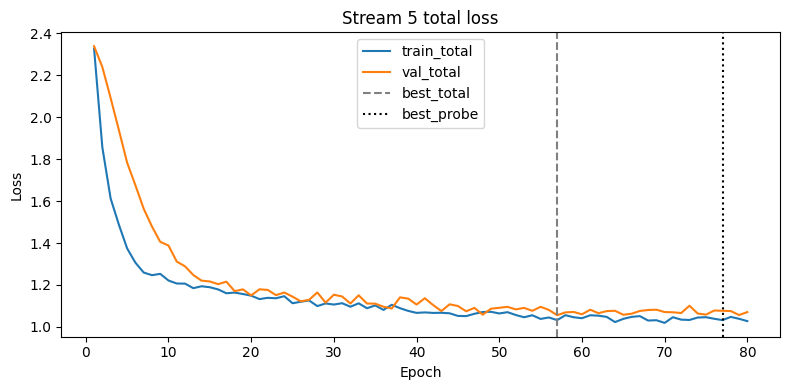

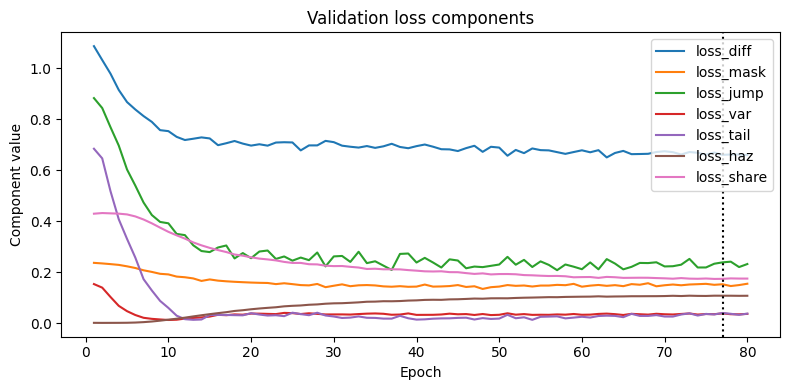

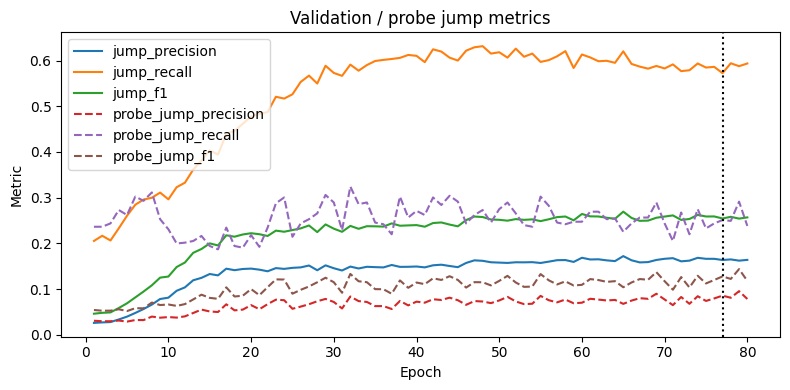

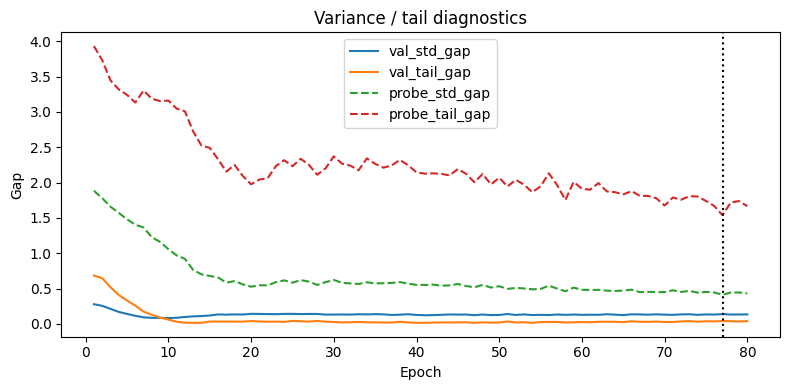

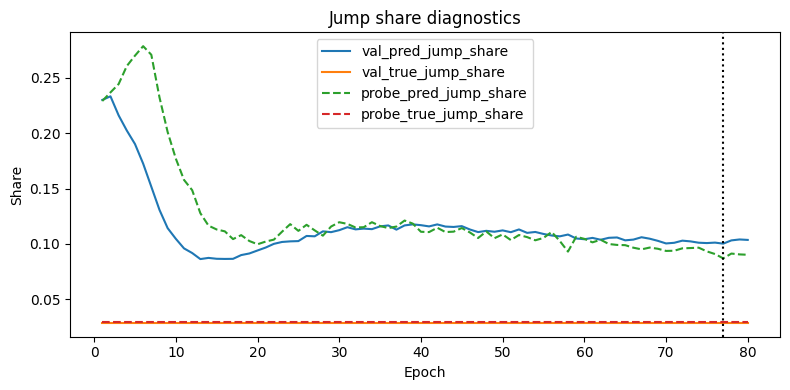

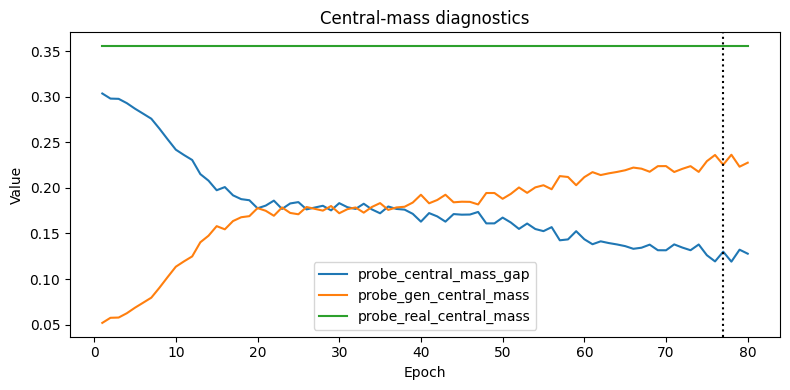

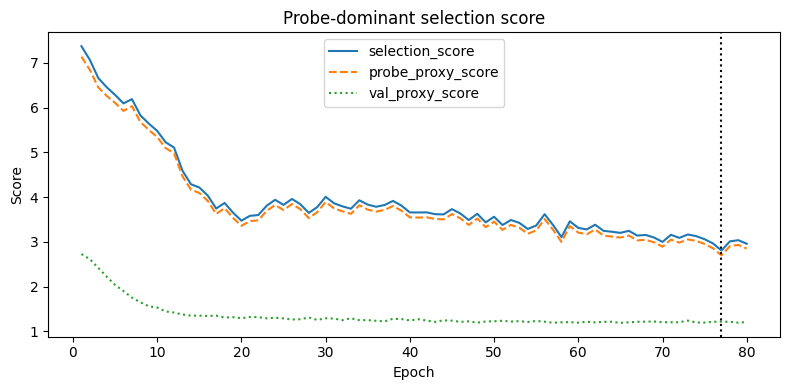

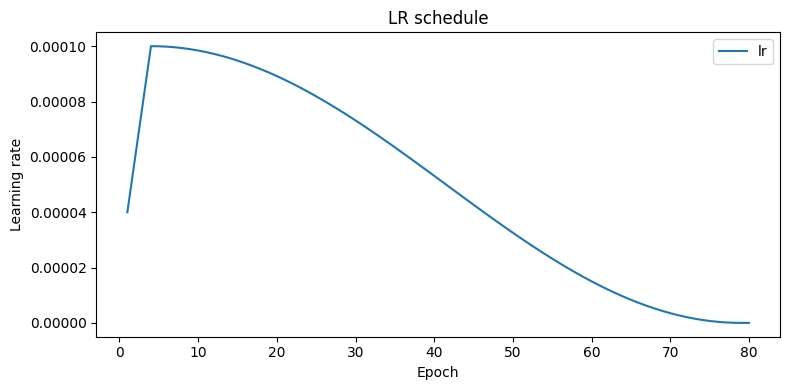

,threshold,temperature,jump_scale,std_gap,tail_gap,central_mass_gap,gen_central_mass,real_central_mass,pred_jump_share,true_jump_share,jump_precision,jump_recall,jump_f1,jump_acc,jump_auroc,jump_ap,proxy_score,feasible_rate,is_feasible
0,0.65,1.4,0.75,0.232950,0.311835,0.128421,0.227323,0.355744,0.023205,0.029005,0.078082,0.061844,0.068979,0.951615,0.679275,0.058782,1.214527,1.0,1
1,0.70,1.0,0.75,0.234936,0.314984,0.128435,0.227309,0.355744,0.024066,0.029005,0.077127,0.063976,0.069894,0.950639,0.679276,0.058783,1.217503,1.0,1
2,0.65,1.4,0.85,0.243587,0.313999,0.128421,0.227323,0.355744,0.023205,0.029005,0.078082,0.061844,0.068979,0.951615,0.679275,0.058782,1.227328,1.0,1
3,0.70,1.0,0.85,0.245937,0.318078,0.128435,0.227309,0.355744,0.024066,0.029005,0.077127,0.063976,0.069894,0.950639,0.679276,0.058783,1.231600,1.0,1
4,0.65,1.4,0.95,0.254654,0.316684,0.128445,0.227299,0.355744,0.023205,0.029005,0.078082,0.061844,0.068979,0.951615,0.679275,0.058782,1.241116,1.0,1
5,0.70,1.0,0.95,0.257367,0.320234,0.128459,0.227285,0.355744,0.024066,0.029005,0.077127,0.063976,0.069894,0.950639,0.679276,0.058783,1.245221,1.0,1
6,0.65,1.4,1.00,0.260335,0.317252,0.128454,0.227290,0.355744,0.023205,0.029005,0.078082,0.061844,0.068979,0.951615,0.679275,0.058782,1.247379,1.0,1
7,0.65,1.2,0.75,0.248376,0.343647,0.128550,0.227194,0.355744,0.030361,0.029005,0.077891,0.080709,0.079221,0.945582,0.679275,0.058782,1.248805,1.0,1
8,0.70,1.0,1.00,0.263222,0.321401,0.128469,0.227275,0.355744,0.024066,0.029005,0.077127,0.063976,0.069894,0.950639,0.679276,0.058783,1.252257,1.0,1
9,0.65,1.2,0.85,0.261486,0.348496,0.128550,0.227194,0.355744,0.030361,0.029005,0.077891,0.080709,0.079221,0.945582,0.679275,0.058782,1.266764,1.0,1



Best calibration:
{
  "threshold": 0.65,
  "temperature": 1.4,
  "jump_scale": 0.75,
  "std_gap": 0.23295006652673086,
  "tail_gap": 0.31183497111002606,
  "central_mass_gap": 0.12842107266567696,
  "gen_central_mass": 0.2273229035818964,
  "real_central_mass": 0.35574397624757337,
  "pred_jump_share": 0.023205244913697243,
  "true_jump_share": 0.029005367308855057,
  "jump_precision": 0.07808249776671423,
  "jump_recall": 0.06184383202099738,
  "jump_f1": 0.06897889133577699,
  "jump_acc": 0.9516148985573446,
  "jump_auroc": 0.6792752861291351,
  "jump_ap": 0.058781575939195085,
  "proxy_score": 1.2145274457576996,
  "feasible_rate": 1.0,
  "is_feasible": 1.0
}


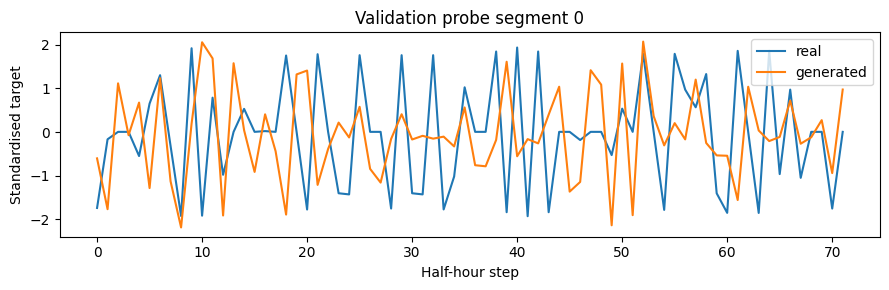

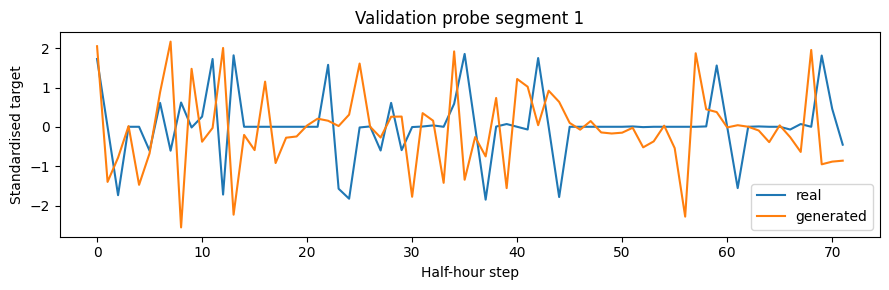

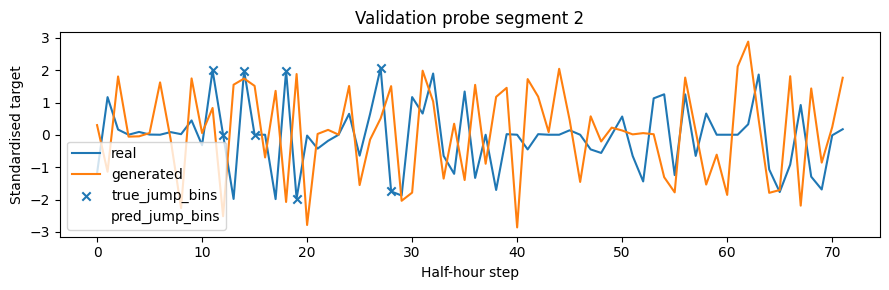

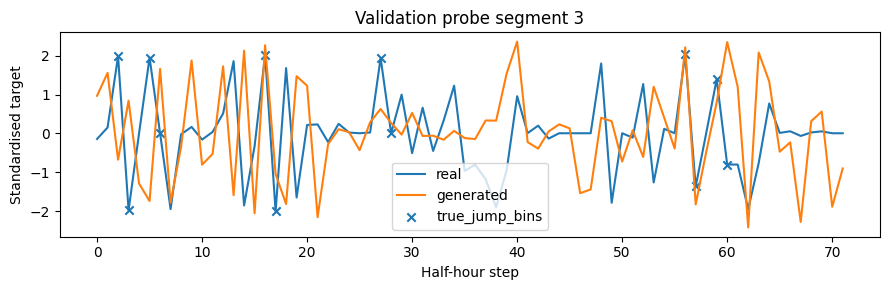

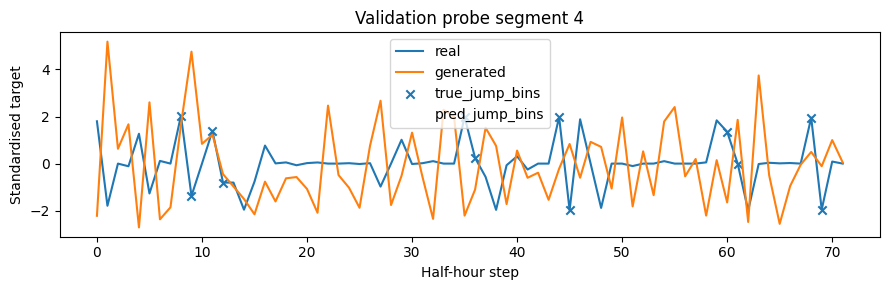

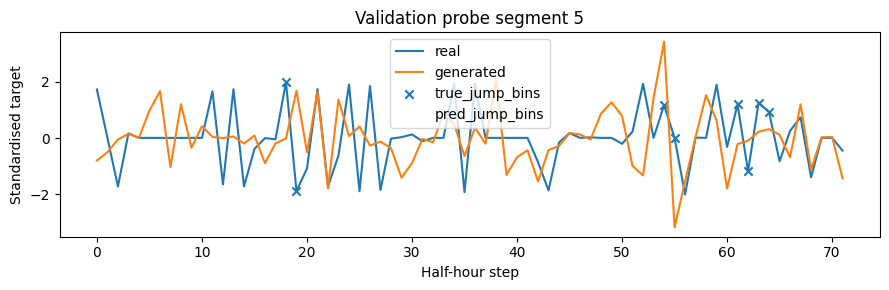

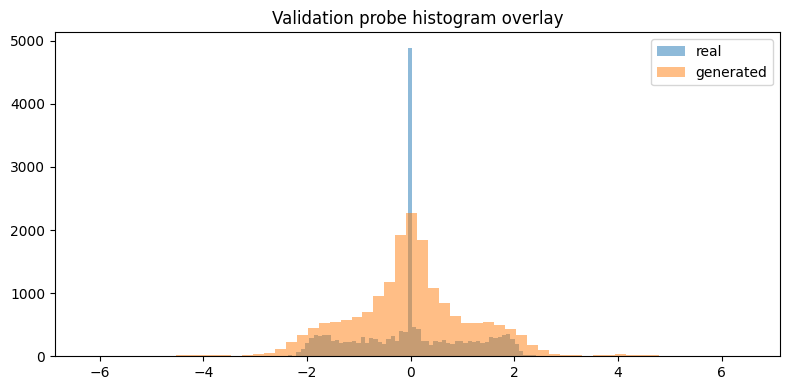

{
  "best_probe_epoch": 77,
  "best_calibration": {
    "threshold": 0.65,
    "temperature": 1.4,
    "jump_scale": 0.75,
    "std_gap": 0.23295006652673086,
    "tail_gap": 0.31183497111002606,
    "central_mass_gap": 0.12842107266567696,
    "gen_central_mass": 0.2273229035818964,
    "real_central_mass": 0.35574397624757337,
    "pred_jump_share": 0.023205244913697243,
    "true_jump_share": 0.029005367308855057,
    "jump_precision": 0.07808249776671423,
    "jump_recall": 0.06184383202099738,
    "jump_f1": 0.06897889133577699,
    "jump_acc": 0.9516148985573446,
    "jump_auroc": 0.6792752861291351,
    "jump_ap": 0.058781575939195085,
    "proxy_score": 1.2145274457576996,
    "feasible_rate": 1.0,
    "is_feasible": 1.0
  },
  "probe_rows": 256,
  "probe_std_gap_final": 0.24749484658241272,
  "probe_tail_gap_final": 0.3254300355911255,
  "probe_central_mass_gap_final": 0.13248697916666666,
  "probe_gen_central_mass_final": 0.22298177083333334,
  "probe_real_central_mass_final"

In [13]:
hist = pd.DataFrame(history)
display(hist.tail())

def save_and_show(fig, path):
    fig.tight_layout()
    fig.savefig(path, dpi=140, bbox_inches="tight")
    plt.show()

# 1. Total loss
fig = plt.figure(figsize=(8, 4))
plt.plot(hist["epoch"], hist["train_loss_total"], label="train_total")
plt.plot(hist["epoch"], hist["val_loss_total"], label="val_total")
plt.axvline(best_total_epoch, color="grey", linestyle="--", label="best_total")
plt.axvline(best_probe_epoch, color="black", linestyle=":", label="best_probe")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Stream 5 total loss")
plt.legend()
save_and_show(fig, PLOT_DIR / "s5_total_loss.png")

# 2. Validation loss components
fig = plt.figure(figsize=(8, 4))
for col in ["val_loss_diff", "val_loss_mask", "val_loss_jump", "val_loss_var", "val_loss_tail", "val_loss_haz", "val_loss_share"]:
    plt.plot(hist["epoch"], hist[col], label=col.replace("val_", ""))
plt.axvline(best_probe_epoch, color="black", linestyle=":")
plt.xlabel("Epoch")
plt.ylabel("Component value")
plt.title("Validation loss components")
plt.legend()
save_and_show(fig, PLOT_DIR / "s5_val_components.png")

# 3. Jump metrics
fig = plt.figure(figsize=(8, 4))
for col in ["val_jump_precision", "val_jump_recall", "val_jump_f1"]:
    plt.plot(hist["epoch"], hist[col], label=col.replace("val_", ""))
for col in ["probe_jump_precision", "probe_jump_recall", "probe_jump_f1"]:
    plt.plot(hist["epoch"], hist[col], linestyle="--", label=col)
plt.axvline(best_probe_epoch, color="black", linestyle=":")
plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title("Validation / probe jump metrics")
plt.legend()
save_and_show(fig, PLOT_DIR / "s5_jump_metrics.png")

# 4. Variance / tail diagnostics
fig = plt.figure(figsize=(8, 4))
plt.plot(hist["epoch"], hist["val_std_gap_proxy"], label="val_std_gap")
plt.plot(hist["epoch"], hist["val_tail_gap_proxy"], label="val_tail_gap")
plt.plot(hist["epoch"], hist["probe_std_gap"], linestyle="--", label="probe_std_gap")
plt.plot(hist["epoch"], hist["probe_tail_gap"], linestyle="--", label="probe_tail_gap")
plt.axvline(best_probe_epoch, color="black", linestyle=":")
plt.xlabel("Epoch")
plt.ylabel("Gap")
plt.title("Variance / tail diagnostics")
plt.legend()
save_and_show(fig, PLOT_DIR / "s5_proxy_diagnostics.png")

# 5. Jump share diagnostics
fig = plt.figure(figsize=(8, 4))
plt.plot(hist["epoch"], hist["val_pred_jump_share"], label="val_pred_jump_share")
plt.plot(hist["epoch"], hist["val_true_jump_share"], label="val_true_jump_share")
plt.plot(hist["epoch"], hist["probe_pred_jump_share"], linestyle="--", label="probe_pred_jump_share")
plt.plot(hist["epoch"], hist["probe_true_jump_share"], linestyle="--", label="probe_true_jump_share")
plt.axvline(best_probe_epoch, color="black", linestyle=":")
plt.xlabel("Epoch")
plt.ylabel("Share")
plt.title("Jump share diagnostics")
plt.legend()
save_and_show(fig, PLOT_DIR / "s5_jump_share.png")

# 6. Central calm-mass diagnostics
fig = plt.figure(figsize=(8, 4))
plt.plot(hist["epoch"], hist["probe_central_mass_gap"], label="probe_central_mass_gap")
plt.plot(hist["epoch"], hist["probe_gen_central_mass"], label="probe_gen_central_mass")
plt.plot(hist["epoch"], hist["probe_real_central_mass"], label="probe_real_central_mass")
plt.axvline(best_probe_epoch, color="black", linestyle=":")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Central-mass diagnostics")
plt.legend()
save_and_show(fig, PLOT_DIR / "s5_central_mass.png")

# 7. Selection score
fig = plt.figure(figsize=(8, 4))
plt.plot(hist["epoch"], hist["selection_score"], label="selection_score")
plt.plot(hist["epoch"], hist["probe_proxy_score"], linestyle="--", label="probe_proxy_score")
plt.plot(hist["epoch"], hist["val_proxy_score"], linestyle=":", label="val_proxy_score")
plt.axvline(best_probe_epoch, color="black", linestyle=":")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Probe-dominant selection score")
plt.legend()
save_and_show(fig, PLOT_DIR / "s5_selection_score.png")

# 8. LR
fig = plt.figure(figsize=(8, 4))
plt.plot(hist["epoch"], hist["lr"], label="lr")
plt.xlabel("Epoch")
plt.ylabel("Learning rate")
plt.title("LR schedule")
plt.legend()
save_and_show(fig, PLOT_DIR / "s5_lr.png")

best_payload = torch.load(OUT_BEST_PROBE, map_location=device)
viz_model = JumpAwareUNet1D(
    seq_len=CFG.seq_len,
    cond_dim=conditioning_dim,
    base_channels=CFG.base_channels,
    dropout=CFG.dropout,
).to(device)
viz_model.load_state_dict(best_payload["model"], strict=True)
viz_model.eval()

val_calib_df = returns_s5.loc[returns_s5["split"].eq("val")].copy().reset_index(drop=True)
val_calib_cond = torch.tensor(val_calib_df[cond_cols].to_numpy(np.float32), device=device)
val_calib_true = val_calib_df[r_cols].to_numpy(np.float32)
val_calib_jump_true = val_calib_df[mask_cols].to_numpy(np.float32)

@torch.no_grad()
def run_calibration_sweep(model_for_eval, cond_tensor, true_x_np, true_jump_np, cfg):
    rows = []

    raw_draws = []
    for draw_idx in range(cfg.n_calib_draws):
        raw_x, raw_prob, raw_jump = ddpm_sample(model_for_eval, cond_tensor)
        raw_draws.append((raw_x, raw_prob, raw_jump))

    for threshold in cfg.calib_thresholds:
        for temperature in cfg.calib_temperatures:
            for jump_scale in cfg.calib_jump_scales:
                draw_stats = []

                for raw_x, raw_prob, raw_jump in raw_draws:
                    x_adj, cal_prob, gate = apply_jump_calibration(
                        raw_x, raw_prob, raw_jump,
                        threshold=threshold,
                        temperature=temperature,
                        jump_scale=jump_scale,
                    )

                    x_adj_np = x_adj.detach().cpu().numpy()
                    cal_prob_np = cal_prob.detach().cpu().numpy()
                    gate_np = gate.detach().cpu().numpy()

                    std_gap = float(np.abs(x_adj_np.std(axis=1) - true_x_np.std(axis=1)).mean())
                    tail_gap_val = float(
                        abs(
                            np.quantile(np.abs(x_adj_np.reshape(-1)), cfg.tail_q)
                            - np.quantile(np.abs(true_x_np.reshape(-1)), cfg.tail_q)
                        )
                    )

                    central_gap, gen_central_mass, real_central_mass = central_mass_gap_np(
                        x_adj_np, true_x_np, tau=cfg.central_mass_tau
                    )

                    pred_share = float(gate_np.mean())
                    true_share = float(true_jump_np.mean())

                    cls = binary_metrics_np(true_jump_np.reshape(-1), cal_prob_np.reshape(-1), threshold=threshold)

                    proxy = calibration_proxy(
                        std_gap=std_gap,
                        tail_gap=tail_gap_val,
                        central_gap=central_gap,
                        pred_share=pred_share,
                        true_share=true_share,
                        f1=cls["f1"],
                    )

                    feasible = feasible_calibration(
                        pred_share=pred_share,
                        true_share=true_share,
                        recall=cls["recall"],
                        cfg=cfg,
                    )

                    draw_stats.append(
                        {
                            "std_gap": std_gap,
                            "tail_gap": tail_gap_val,
                            "central_mass_gap": central_gap,
                            "gen_central_mass": gen_central_mass,
                            "real_central_mass": real_central_mass,
                            "pred_jump_share": pred_share,
                            "true_jump_share": true_share,
                            "jump_precision": cls["precision"],
                            "jump_recall": cls["recall"],
                            "jump_f1": cls["f1"],
                            "jump_acc": cls["acc"],
                            "jump_auroc": cls["auroc"],
                            "jump_ap": cls["ap"],
                            "proxy_score": proxy,
                            "feasible": float(feasible),
                        }
                    )

                mean_row = {
                    "threshold": threshold,
                    "temperature": temperature,
                    "jump_scale": jump_scale,
                    "std_gap": float(np.mean([d["std_gap"] for d in draw_stats])),
                    "tail_gap": float(np.mean([d["tail_gap"] for d in draw_stats])),
                    "central_mass_gap": float(np.mean([d["central_mass_gap"] for d in draw_stats])),
                    "gen_central_mass": float(np.mean([d["gen_central_mass"] for d in draw_stats])),
                    "real_central_mass": float(np.mean([d["real_central_mass"] for d in draw_stats])),
                    "pred_jump_share": float(np.mean([d["pred_jump_share"] for d in draw_stats])),
                    "true_jump_share": float(np.mean([d["true_jump_share"] for d in draw_stats])),
                    "jump_precision": float(np.mean([d["jump_precision"] for d in draw_stats])),
                    "jump_recall": float(np.mean([d["jump_recall"] for d in draw_stats])),
                    "jump_f1": float(np.mean([d["jump_f1"] for d in draw_stats])),
                    "jump_acc": float(np.mean([d["jump_acc"] for d in draw_stats])),
                    "jump_auroc": float(np.nanmean([d["jump_auroc"] for d in draw_stats])),
                    "jump_ap": float(np.nanmean([d["jump_ap"] for d in draw_stats])),
                    "proxy_score": float(np.mean([d["proxy_score"] for d in draw_stats])),
                    "feasible_rate": float(np.mean([d["feasible"] for d in draw_stats])),
                }
                rows.append(mean_row)

    out = pd.DataFrame(rows)

    out["is_feasible"] = (
        (out["pred_jump_share"] >= cfg.calib_min_pred_share_frac * out["true_jump_share"])
        & (out["pred_jump_share"] <= cfg.calib_max_pred_share_mult * out["true_jump_share"])
        & (out["jump_recall"] >= cfg.calib_min_recall)
    ).astype(int)

    feasible_out = out.loc[out["is_feasible"] == 1].copy()
    if len(feasible_out) > 0:
        ranked = feasible_out.sort_values(
            ["proxy_score", "central_mass_gap", "std_gap", "tail_gap", "jump_f1"],
            ascending=[True, True, True, True, False]
        ).reset_index(drop=True)
    else:
        print("Warning: no feasible calibration rows found; falling back to global ranking.")
        ranked = out.sort_values(
            ["proxy_score", "central_mass_gap", "std_gap", "tail_gap", "jump_f1"],
            ascending=[True, True, True, True, False]
        ).reset_index(drop=True)

    return ranked, out

calib_ranked, calib_full = run_calibration_sweep(
    viz_model, val_calib_cond, val_calib_true, val_calib_jump_true, CFG
)

display(calib_ranked.head(15))
calib_full.to_csv(OUT_CALIB_CSV, index=False)

best_calib = calib_ranked.iloc[0].to_dict()
with open(OUT_CALIB_JSON, "w") as f:
    json.dump(best_calib, f, indent=2)

print("\nBest calibration:")
print(json.dumps(best_calib, indent=2))

probe_raw_x, probe_raw_prob, probe_raw_jump = ddpm_sample(viz_model, probe_cond)
probe_x_adj, probe_prob_adj, probe_gate = apply_jump_calibration(
    probe_raw_x,
    probe_raw_prob,
    probe_raw_jump,
    threshold=float(best_calib["threshold"]),
    temperature=float(best_calib["temperature"]),
    jump_scale=float(best_calib["jump_scale"]),
)

probe_sample_np = probe_x_adj.detach().cpu().numpy()
probe_gate_np = probe_gate.detach().cpu().numpy()

n_show = min(6, len(probe_df))
for i in range(n_show):
    fig = plt.figure(figsize=(9, 3))
    plt.plot(probe_true[i], label="real")
    plt.plot(probe_sample_np[i], label="generated")
    jump_true_idx = np.where(probe_jump_true[i] > 0.5)[0]
    if len(jump_true_idx) > 0:
        plt.scatter(jump_true_idx, probe_true[i][jump_true_idx], marker="x", label="true_jump_bins")
    jump_pred_idx = np.where(probe_gate_np[i] > 0.5)[0]
    if len(jump_pred_idx) > 0:
        plt.scatter(jump_pred_idx, probe_sample_np[i][jump_pred_idx], marker="o", facecolors="none", label="pred_jump_bins")
    plt.title(f"Validation probe segment {i}")
    plt.xlabel("Half-hour step")
    plt.ylabel("Standardised target")
    plt.legend()
    save_and_show(fig, PLOT_DIR / f"s5_probe_segment_{i}.png")

fig = plt.figure(figsize=(8, 4))
plt.hist(probe_true.reshape(-1), bins=60, alpha=0.5, label="real")
plt.hist(probe_sample_np.reshape(-1), bins=60, alpha=0.5, label="generated")
plt.title("Validation probe histogram overlay")
plt.legend()
save_and_show(fig, PLOT_DIR / "s5_probe_hist.png")

probe_central_gap, probe_gen_central_mass, probe_real_central_mass = central_mass_gap_np(
    probe_sample_np, probe_true, tau=CFG.central_mass_tau
)

probe_summary = {
    "best_probe_epoch": best_probe_epoch,
    "best_calibration": best_calib,
    "probe_rows": int(len(probe_df)),
    "probe_std_gap_final": float(np.abs(probe_sample_np.std(axis=1) - probe_true.std(axis=1)).mean()),
    "probe_tail_gap_final": float(
        abs(
            np.quantile(np.abs(probe_sample_np.reshape(-1)), CFG.tail_q)
            - np.quantile(np.abs(probe_true.reshape(-1)), CFG.tail_q)
        )
    ),
    "probe_central_mass_gap_final": float(probe_central_gap),
    "probe_gen_central_mass_final": float(probe_gen_central_mass),
    "probe_real_central_mass_final": float(probe_real_central_mass),
    "probe_pred_jump_share_final": float(probe_gate_np.mean()),
    "probe_true_jump_share_final": float(probe_jump_true.mean()),
}
with open(OUT_PROBE_JSON, "w") as f:
    json.dump(probe_summary, f, indent=2)

print(json.dumps(probe_summary, indent=2))
print("\nSaved:")
print(" ", OUT_CALIB_CSV)
print(" ", OUT_CALIB_JSON)
print(" ", OUT_PROBE_JSON)

## 14. Optional next step inside this notebook

If runtime is still cheap, the next clean refinement is not a full retune. It is a narrow search over a few jump-specific weights, run one at a time against the same probe-dominant objective:
- `lambda_share`
- `lambda_mask`
- `lambda_jump`
- `lambda_tail`
- `focal_gamma`

That keeps Stream 5 disciplined while still exploiting its lower compute cost than the Neural SDE.

In [14]:
# ============================================================
# 15. Optional thorough refinement sweep
# Narrow but serious search around the jump-specific settings.
# ============================================================

from dataclasses import replace, asdict
import itertools, time, gc, random

REFINE_DIR = DATA_DIR / "s5_optional_refinement"
REFINE_DIR.mkdir(parents=True, exist_ok=True)

REFINE_RESULTS_CSV = REFINE_DIR / "s5_refinement_results.csv"
REFINE_BEST_JSON = REFINE_DIR / "s5_refinement_best.json"

RUN_STAGE1 = True
RUN_STAGE2 = True
SKIP_COMPLETED = True

OPTIONAL_SEED_BASE = SEED + 1000

IMPORTANT_CFG_KEYS = [
    "base_channels",
    "denoise_target",
    "lambda_mask",
    "lambda_jump",
    "lambda_tail",
    "lambda_share",
    "focal_gamma",
    "jump_threshold",
    "max_epochs",
    "min_epochs",
    "patience",
]

def seed_everything_local(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def make_lr_scheduler_local(optimizer_local, cfg_local):
    def lr_lambda(epoch_idx):
        if epoch_idx < cfg_local.warmup_epochs:
            return float(epoch_idx + 1) / max(cfg_local.warmup_epochs, 1)
        progress = (epoch_idx - cfg_local.warmup_epochs) / max(cfg_local.max_epochs - cfg_local.warmup_epochs, 1)
        progress = min(max(progress, 0.0), 1.0)
        return 0.5 * (1.0 + math.cos(math.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optimizer_local, lr_lambda=lr_lambda)

def append_result_row(row: dict):
    row_df = pd.DataFrame([row])
    if REFINE_RESULTS_CSV.exists():
        prev = pd.read_csv(REFINE_RESULTS_CSV)
        out = pd.concat([prev, row_df], ignore_index=True)
    else:
        out = row_df.copy()
    out.to_csv(REFINE_RESULTS_CSV, index=False)
    return out

def maybe_get_existing_results():
    if REFINE_RESULTS_CSV.exists():
        return pd.read_csv(REFINE_RESULTS_CSV)
    return pd.DataFrame()

@torch.no_grad()
def evaluate_calibrated_probe_multi(
    model_for_eval: nn.Module,
    cfg_local,
    threshold: float,
    temperature: float,
    jump_scale: float,
    n_draws: int | None = None,
    seed_base: int = 0,
):
    n_draws = cfg_local.n_calib_draws if n_draws is None else n_draws
    rows = []

    for draw_idx in range(n_draws):
        seed_everything_local(seed_base + draw_idx)

        raw_x, raw_prob, raw_jump = ddpm_sample(model_for_eval, probe_cond)
        x_adj, cal_prob, gate = apply_jump_calibration(
            raw_x, raw_prob, raw_jump,
            threshold=threshold,
            temperature=temperature,
            jump_scale=jump_scale,
        )

        x_adj_np = x_adj.detach().cpu().numpy()
        cal_prob_np = cal_prob.detach().cpu().numpy()
        gate_np = gate.detach().cpu().numpy()

        std_gap = float(np.abs(x_adj_np.std(axis=1) - probe_true.std(axis=1)).mean())
        tail_gap_val = float(
            abs(
                np.quantile(np.abs(x_adj_np.reshape(-1)), cfg_local.tail_q)
                - np.quantile(np.abs(probe_true.reshape(-1)), cfg_local.tail_q)
            )
        )

        central_gap, gen_central_mass, real_central_mass = central_mass_gap_np(
            x_adj_np, probe_true, tau=cfg_local.central_mass_tau
        )

        pred_share = float(gate_np.mean())
        true_share = float(probe_jump_true.mean())

        cls = binary_metrics_np(probe_jump_true.reshape(-1), cal_prob_np.reshape(-1), threshold=threshold)

        proxy = calibration_proxy(
            std_gap=std_gap,
            tail_gap=tail_gap_val,
            central_gap=central_gap,
            pred_share=pred_share,
            true_share=true_share,
            f1=cls["f1"],
        )

        feasible = feasible_calibration(
            pred_share=pred_share,
            true_share=true_share,
            recall=cls["recall"],
            cfg=cfg_local,
        )

        rows.append({
            "probe_std_gap": std_gap,
            "probe_tail_gap": tail_gap_val,
            "probe_central_mass_gap": central_gap,
            "probe_gen_central_mass": gen_central_mass,
            "probe_real_central_mass": real_central_mass,
            "probe_pred_jump_share": pred_share,
            "probe_true_jump_share": true_share,
            "probe_jump_precision": cls["precision"],
            "probe_jump_recall": cls["recall"],
            "probe_jump_f1": cls["f1"],
            "probe_jump_acc": cls["acc"],
            "probe_jump_auroc": cls["auroc"],
            "probe_jump_ap": cls["ap"],
            "probe_proxy_score": proxy,
            "probe_feasible": float(feasible),
        })

    df = pd.DataFrame(rows)
    out = {k: float(df[k].mean()) for k in df.columns}
    return out

def train_refinement_trial(
    cfg_local,
    trial_name: str,
    stage_name: str,
    seed: int,
    verbose: bool = True,
):
    seed_everything_local(seed)

    model_local = JumpAwareUNet1D(
        seq_len=cfg_local.seq_len,
        cond_dim=conditioning_dim,
        base_channels=cfg_local.base_channels,
        dropout=cfg_local.dropout,
    ).to(device)

    optimizer_local = torch.optim.AdamW(
        model_local.parameters(),
        lr=cfg_local.lr,
        weight_decay=cfg_local.weight_decay,
    )
    scheduler_lr_local = make_lr_scheduler_local(optimizer_local, cfg_local)
    scaler_local = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())
    ema_local = EMA(model_local, decay=cfg_local.ema_decay)

    def compute_losses_local(batch):
        x0 = batch["x0"].to(device, non_blocking=True)
        jump_mask = batch["jump_mask"].to(device, non_blocking=True)
        jump_size = batch["jump_size"].to(device, non_blocking=True)
        cond = batch["cond"].to(device, non_blocking=True)
        haz = batch["haz"].to(device, non_blocking=True)

        bsz = x0.shape[0]
        t = torch.randint(0, scheduler.n_steps, (bsz,), device=device)
        noise = torch.randn_like(x0)
        xt = scheduler.q_sample(x0, t, noise)

        pred_eps, mask_logits, jump_pred = model_local(xt, t, cond)

        if cfg_local.denoise_target == "eps":
            denoise_target = noise
            diff_loss = F.mse_loss(pred_eps, denoise_target)
            x0_hat = scheduler.predict_x0_from_eps(xt, t, pred_eps)
        else:
            denoise_target = scheduler.predict_v(x0, noise, t)
            diff_loss = F.mse_loss(pred_eps, denoise_target)
            x0_hat = scheduler.predict_x0_from_v(xt, t, pred_eps)

        mask_loss = focal_bce_with_logits(mask_logits, jump_mask, pos_weight, cfg_local.focal_gamma)

        if jump_mask.sum() > 0:
            jump_loss = F.huber_loss(jump_pred[jump_mask > 0.5], jump_size[jump_mask > 0.5], delta=1.0)
            jump_mae = (jump_pred[jump_mask > 0.5] - jump_size[jump_mask > 0.5]).abs().mean()
        else:
            jump_loss = torch.tensor(0.0, device=device)
            jump_mae = torch.tensor(0.0, device=device)

        var_loss = F.mse_loss(x0_hat.std(dim=1), x0.std(dim=1))
        tail_loss = tail_gap(x0_hat, x0, cfg_local.tail_q)
        gate_rate = torch.sigmoid(mask_logits).mean(dim=1)
        hazard_target = torch.sigmoid(haz.max(dim=1).values)
        haz_loss = F.mse_loss(gate_rate, hazard_target)

        pred_share_batch = torch.sigmoid(mask_logits).mean()
        true_share_batch = jump_mask.float().mean()
        share_loss = torch.abs(pred_share_batch - true_share_batch)

        total = (
            diff_loss
            + cfg_local.lambda_mask * mask_loss
            + cfg_local.lambda_jump * jump_loss
            + cfg_local.lambda_var * var_loss
            + cfg_local.lambda_tail * tail_loss
            + cfg_local.lambda_haz * haz_loss
            + cfg_local.lambda_share * share_loss
        )

        with torch.no_grad():
            std_gap = (x0_hat.std(dim=1) - x0.std(dim=1)).abs().mean()
            tail_gap_proxy = tail_gap(x0_hat, x0, cfg_local.tail_q)
            pred_jump_prob = torch.sigmoid(mask_logits)
            pred_jump_share = (pred_jump_prob >= cfg_local.jump_threshold).float().mean()
            true_jump_share = jump_mask.mean()

        metrics = {
            "loss_total": float(total.detach().cpu()),
            "loss_diff": float(diff_loss.detach().cpu()),
            "loss_mask": float(mask_loss.detach().cpu()),
            "loss_jump": float(jump_loss.detach().cpu()),
            "loss_var": float(var_loss.detach().cpu()),
            "loss_tail": float(tail_loss.detach().cpu()),
            "loss_haz": float(haz_loss.detach().cpu()),
            "loss_share": float(share_loss.detach().cpu()),
            "std_gap_proxy": float(std_gap.detach().cpu()),
            "tail_gap_proxy": float(tail_gap_proxy.detach().cpu()),
            "pred_jump_share": float(pred_jump_share.detach().cpu()),
            "true_jump_share": float(true_jump_share.detach().cpu()),
            "jump_mae_on_true": float(jump_mae.detach().cpu()),
        }
        return total, metrics

    @torch.no_grad()
    def evaluate_local(model_for_eval: nn.Module, loader: DataLoader):
        model_for_eval.eval()
        sums = {}
        n_batches = 0
        all_y_true = []
        all_y_prob = []

        for batch in loader:
            x0 = batch["x0"].to(device, non_blocking=True)
            jump_mask = batch["jump_mask"].to(device, non_blocking=True)
            jump_size = batch["jump_size"].to(device, non_blocking=True)
            cond = batch["cond"].to(device, non_blocking=True)
            haz = batch["haz"].to(device, non_blocking=True)

            bsz = x0.shape[0]
            t = torch.randint(0, scheduler.n_steps, (bsz,), device=device)
            noise = torch.randn_like(x0)
            xt = scheduler.q_sample(x0, t, noise)

            with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
                pred_eps, mask_logits, jump_pred = model_for_eval(xt, t, cond)

                if cfg_local.denoise_target == "eps":
                    denoise_target = noise
                    diff_loss = F.mse_loss(pred_eps, denoise_target)
                    x0_hat = scheduler.predict_x0_from_eps(xt, t, pred_eps)
                else:
                    denoise_target = scheduler.predict_v(x0, noise, t)
                    diff_loss = F.mse_loss(pred_eps, denoise_target)
                    x0_hat = scheduler.predict_x0_from_v(xt, t, pred_eps)

                mask_loss = focal_bce_with_logits(mask_logits, jump_mask, pos_weight, cfg_local.focal_gamma)

                if jump_mask.sum() > 0:
                    jump_loss = F.huber_loss(jump_pred[jump_mask > 0.5], jump_size[jump_mask > 0.5], delta=1.0)
                    jump_mae = (jump_pred[jump_mask > 0.5] - jump_size[jump_mask > 0.5]).abs().mean()
                else:
                    jump_loss = torch.tensor(0.0, device=device)
                    jump_mae = torch.tensor(0.0, device=device)

                var_loss = F.mse_loss(x0_hat.std(dim=1), x0.std(dim=1))
                tail_loss_v = tail_gap(x0_hat, x0, cfg_local.tail_q)
                gate_rate = torch.sigmoid(mask_logits).mean(dim=1)
                hazard_target = torch.sigmoid(haz.max(dim=1).values)
                haz_loss = F.mse_loss(gate_rate, hazard_target)
                share_loss = share_gap(mask_logits, jump_mask)

                total = (
                    diff_loss
                    + cfg_local.lambda_mask * mask_loss
                    + cfg_local.lambda_jump * jump_loss
                    + cfg_local.lambda_var * var_loss
                    + cfg_local.lambda_tail * tail_loss_v
                    + cfg_local.lambda_haz * haz_loss
                    + cfg_local.lambda_share * share_loss
                )

            pred_prob = torch.sigmoid(mask_logits)
            batch_stats = {
                "loss_total": float(total.detach().cpu()),
                "loss_diff": float(diff_loss.detach().cpu()),
                "loss_mask": float(mask_loss.detach().cpu()),
                "loss_jump": float(jump_loss.detach().cpu()),
                "loss_var": float(var_loss.detach().cpu()),
                "loss_tail": float(tail_loss_v.detach().cpu()),
                "loss_haz": float(haz_loss.detach().cpu()),
                "loss_share": float(share_loss.detach().cpu()),
                "std_gap_proxy": float(((x0_hat.std(dim=1) - x0.std(dim=1)).abs().mean()).detach().cpu()),
                "tail_gap_proxy": float(tail_loss_v.detach().cpu()),
                "pred_jump_share": float(((pred_prob >= cfg_local.jump_threshold).float().mean()).detach().cpu()),
                "true_jump_share": float(jump_mask.mean().detach().cpu()),
                "jump_mae_on_true": float(jump_mae.detach().cpu()),
            }

            for k, v in batch_stats.items():
                sums[k] = sums.get(k, 0.0) + float(v)
            n_batches += 1
            all_y_true.append(jump_mask.detach().cpu().numpy().reshape(-1))
            all_y_prob.append(pred_prob.detach().cpu().numpy().reshape(-1))

        out = {k: v / max(n_batches, 1) for k, v in sums.items()}
        y_true = np.concatenate(all_y_true)
        y_prob = np.concatenate(all_y_prob)
        out.update(summarise_binary_metrics(y_true, y_prob, threshold=cfg_local.jump_threshold))
        out["proxy_score"] = (
            out["loss_total"]
            + 0.25 * out["std_gap_proxy"]
            + 0.25 * out["tail_gap_proxy"]
            + 0.25 * abs(out["pred_jump_share"] - out["true_jump_share"])
            + 0.10 * (1.0 - out["jump_f1"])
        )
        return out

    best_total_local = float("inf")
    best_probe_local = float("inf")
    best_total_epoch_local = -1
    best_probe_epoch_local = -1
    bad_epochs_local = 0
    best_probe_state = None
    local_history = []

    t0 = time.time()

    for epoch in range(1, cfg_local.max_epochs + 1):
        model_local.train()
        train_sums = {}
        n_batches = 0

        for batch in train_loader:
            optimizer_local.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
                total, metrics = compute_losses_local(batch)

            scaler_local.scale(total).backward()
            scaler_local.unscale_(optimizer_local)
            torch.nn.utils.clip_grad_norm_(model_local.parameters(), cfg_local.grad_clip)
            scaler_local.step(optimizer_local)
            scaler_local.update()
            ema_local.update(model_local)

            for k, v in metrics.items():
                train_sums[k] = train_sums.get(k, 0.0) + float(v)
            n_batches += 1

        scheduler_lr_local.step()
        train_metrics = {f"train_{k}": v / max(n_batches, 1) for k, v in train_sums.items()}

        eval_model_local = JumpAwareUNet1D(
            seq_len=cfg_local.seq_len,
            cond_dim=conditioning_dim,
            base_channels=cfg_local.base_channels,
            dropout=cfg_local.dropout,
        ).to(device)
        ema_local.copy_to(eval_model_local)

        val_metrics_raw = evaluate_local(eval_model_local, val_loader)
        val_metrics = {f"val_{k}": v for k, v in val_metrics_raw.items()}

        probe_metrics = evaluate_probe_epoch(
            eval_model_local,
            probe_cond,
            probe_true,
            probe_jump_true,
            threshold=cfg_local.jump_threshold,
            temperature=1.0,
            jump_scale=1.0,
        )

        row = {
            "epoch": epoch,
            "lr": optimizer_local.param_groups[0]["lr"],
            **train_metrics,
            **val_metrics,
            **probe_metrics,
        }
        row["selection_score"] = (
            row["probe_std_gap"]
            + row["probe_tail_gap"]
            + 1.5 * row["probe_central_mass_gap"]
            + 2.0 * abs(row["probe_pred_jump_share"] - row["probe_true_jump_share"])
            + 0.5 * (1.0 - row["probe_jump_f1"])
            + 0.10 * row["val_loss_total"]
        )
        local_history.append(row)

        if verbose:
            print(
                f"[{trial_name}] epoch {epoch:03d} | "
                f"train={row['train_loss_total']:.4f} | "
                f"val={row['val_loss_total']:.4f} | "
                f"probe_std={row['probe_std_gap']:.4f} | "
                f"probe_tail={row['probe_tail_gap']:.4f} | "
                f"probe_central={row['probe_central_mass_gap']:.4f} | "
                f"probe_share={row['probe_pred_jump_share']:.4f}/{row['probe_true_jump_share']:.4f} | "
                f"probe_f1={row['probe_jump_f1']:.4f} | "
                f"sel={row['selection_score']:.4f}"
            )

        improved_total = row["val_loss_total"] < (best_total_local - cfg_local.min_delta)
        improved_probe = row["selection_score"] < (best_probe_local - cfg_local.min_delta)

        if improved_total:
            best_total_local = row["val_loss_total"]
            best_total_epoch_local = epoch

        if improved_probe:
            best_probe_local = row["selection_score"]
            best_probe_epoch_local = epoch
            best_probe_state = copy.deepcopy(eval_model_local.state_dict())

        if improved_total or improved_probe:
            bad_epochs_local = 0
        else:
            bad_epochs_local += 1

        del eval_model_local
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        if epoch >= cfg_local.min_epochs and bad_epochs_local >= cfg_local.patience:
            if verbose:
                print(f"[{trial_name}] early stop at epoch {epoch}")
            break

    epochs_run = epoch
    runtime_sec = time.time() - t0

    best_model_local = JumpAwareUNet1D(
        seq_len=cfg_local.seq_len,
        cond_dim=conditioning_dim,
        base_channels=cfg_local.base_channels,
        dropout=cfg_local.dropout,
    ).to(device)
    best_model_local.load_state_dict(best_probe_state, strict=True)
    best_model_local.eval()

    calib_ranked_local, calib_full_local = run_calibration_sweep(
        best_model_local, val_calib_cond, val_calib_true, val_calib_jump_true, cfg_local
    )
    best_calib_local = calib_ranked_local.iloc[0].to_dict()

    probe_calib_local = evaluate_calibrated_probe_multi(
        best_model_local,
        cfg_local,
        threshold=float(best_calib_local["threshold"]),
        temperature=float(best_calib_local["temperature"]),
        jump_scale=float(best_calib_local["jump_scale"]),
        n_draws=cfg_local.n_calib_draws,
        seed_base=seed + 5000,
    )

    trial_summary = {
        "stage": stage_name,
        "trial_name": trial_name,
        "seed": seed,
        "runtime_sec": float(runtime_sec),
        "epochs_run": int(epochs_run),
        "best_total_epoch": int(best_total_epoch_local),
        "best_probe_epoch": int(best_probe_epoch_local),
        "best_total_val_loss": float(best_total_local),
        "best_probe_selection_score": float(best_probe_local),
        "calib_threshold": float(best_calib_local["threshold"]),
        "calib_temperature": float(best_calib_local["temperature"]),
        "calib_jump_scale": float(best_calib_local["jump_scale"]),
        "calib_proxy_score": float(best_calib_local["proxy_score"]),
        "calib_std_gap": float(best_calib_local["std_gap"]),
        "calib_tail_gap": float(best_calib_local["tail_gap"]),
        "calib_central_mass_gap": float(best_calib_local["central_mass_gap"]),
        "calib_pred_jump_share": float(best_calib_local["pred_jump_share"]),
        "calib_true_jump_share": float(best_calib_local["true_jump_share"]),
        "calib_jump_f1": float(best_calib_local["jump_f1"]),
        "calib_jump_recall": float(best_calib_local["jump_recall"]),
        "calib_is_feasible": int(best_calib_local.get("is_feasible", 0)),
        "probe_calib_proxy": float(probe_calib_local["probe_proxy_score"]),
        "probe_calib_std_gap": float(probe_calib_local["probe_std_gap"]),
        "probe_calib_tail_gap": float(probe_calib_local["probe_tail_gap"]),
        "probe_calib_central_mass_gap": float(probe_calib_local["probe_central_mass_gap"]),
        "probe_calib_pred_jump_share": float(probe_calib_local["probe_pred_jump_share"]),
        "probe_calib_true_jump_share": float(probe_calib_local["probe_true_jump_share"]),
        "probe_calib_jump_f1": float(probe_calib_local["probe_jump_f1"]),
        "probe_calib_jump_recall": float(probe_calib_local["probe_jump_recall"]),
    }

    for k in IMPORTANT_CFG_KEYS:
        trial_summary[f"cfg__{k}"] = asdict(cfg_local)[k]

    trial_summary["updates_json"] = json.dumps({
        k: asdict(cfg_local)[k] for k in IMPORTANT_CFG_KEYS if asdict(cfg_local)[k] != asdict(CFG)[k]
    })

    # small per-trial artifacts
    trial_art_dir = REFINE_DIR / trial_name
    trial_art_dir.mkdir(parents=True, exist_ok=True)
    pd.DataFrame(local_history).to_csv(trial_art_dir / "history.csv", index=False)
    calib_full_local.to_csv(trial_art_dir / "calibration_full.csv", index=False)
    with open(trial_art_dir / "summary.json", "w") as f:
        json.dump(trial_summary, f, indent=2)

    del best_model_local, model_local, optimizer_local, scheduler_lr_local, scaler_local, ema_local
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return trial_summary

# ------------------------------------------------------------
# Search spaces
# ------------------------------------------------------------

baseline_cfg = replace(CFG)

stage1_space = {
    "lambda_share": [0.10, 0.25, 0.40, 0.60],
    "lambda_mask": [0.50, 0.75, 1.00, 1.25],
    "lambda_jump": [0.75, 1.00, 1.25, 1.50],
    "lambda_tail": [0.05, 0.10, 0.20, 0.30],
    "focal_gamma": [1.50, 2.00, 2.50, 3.00],
    "base_channels": [48, 64, 96],
    "denoise_target": ["eps", "v"],
}

existing = maybe_get_existing_results()
done_trials = set(existing["trial_name"].tolist()) if len(existing) else set()

def run_trial_if_needed(stage_name, trial_name, cfg_local, seed_local):
    if SKIP_COMPLETED and trial_name in done_trials:
        print(f"Skipping existing trial: {trial_name}")
        return None
    print(f"\n=== Running {trial_name} ===")
    row = train_refinement_trial(
        cfg_local=cfg_local,
        trial_name=trial_name,
        stage_name=stage_name,
        seed=seed_local,
        verbose=False,
    )
    out = append_result_row(row)
    done_trials.add(trial_name)
    display(out.sort_values("probe_calib_proxy").head(10))
    return row

# ------------------------------------------------------------
# Stage 1: baseline + one-at-a-time scan
# ------------------------------------------------------------

if RUN_STAGE1:
    _ = run_trial_if_needed(
        stage_name="stage1",
        trial_name="stage1__baseline",
        cfg_local=baseline_cfg,
        seed_local=OPTIONAL_SEED_BASE,
    )

    trial_counter = 1
    for param_name, values in stage1_space.items():
        for value in values:
            if getattr(baseline_cfg, param_name) == value:
                continue
            cfg_trial = replace(baseline_cfg, **{param_name: value})
            trial_name = f"stage1__{param_name}__{value}"
            _ = run_trial_if_needed(
                stage_name="stage1",
                trial_name=trial_name,
                cfg_local=cfg_trial,
                seed_local=OPTIONAL_SEED_BASE + trial_counter,
            )
            trial_counter += 1

stage1_results = maybe_get_existing_results()
stage1_results = stage1_results.loc[stage1_results["stage"] == "stage1"].copy()
display(stage1_results.sort_values("probe_calib_proxy").head(15))

# ------------------------------------------------------------
# Stage 2: local joint search around best stage-1 settings
# ------------------------------------------------------------

def best_value_from_stage1(param_name, baseline_value):
    if len(stage1_results) == 0:
        return baseline_value
    param_col = f"cfg__{param_name}"
    subset = stage1_results.loc[
        stage1_results["trial_name"].str.contains(f"stage1__{param_name}__") | (stage1_results["trial_name"] == "stage1__baseline")
    ].copy()
    if len(subset) == 0:
        return baseline_value
    subset = subset.sort_values("probe_calib_proxy", ascending=True)
    return subset.iloc[0][param_col]

if RUN_STAGE2 and len(stage1_results) > 0:
    best_stage1_updates = {
        "lambda_share": best_value_from_stage1("lambda_share", baseline_cfg.lambda_share),
        "lambda_mask": best_value_from_stage1("lambda_mask", baseline_cfg.lambda_mask),
        "lambda_jump": best_value_from_stage1("lambda_jump", baseline_cfg.lambda_jump),
        "lambda_tail": best_value_from_stage1("lambda_tail", baseline_cfg.lambda_tail),
        "focal_gamma": best_value_from_stage1("focal_gamma", baseline_cfg.focal_gamma),
        "base_channels": int(best_value_from_stage1("base_channels", baseline_cfg.base_channels)),
        "denoise_target": best_value_from_stage1("denoise_target", baseline_cfg.denoise_target),
    }

    print("Best stage-1 updates:")
    print(best_stage1_updates)

    # Keep the stage-2 search narrow but real:
    # 4 jump-shape parameters, 2 candidate values each -> 16 trials
    stage2_space = {
        "lambda_share": sorted(set([baseline_cfg.lambda_share, float(best_stage1_updates["lambda_share"])])),
        "lambda_mask": sorted(set([baseline_cfg.lambda_mask, float(best_stage1_updates["lambda_mask"])])),
        "lambda_tail": sorted(set([baseline_cfg.lambda_tail, float(best_stage1_updates["lambda_tail"])])),
        "focal_gamma": sorted(set([baseline_cfg.focal_gamma, float(best_stage1_updates["focal_gamma"])])),
    }

    fixed_stage2 = {
        "lambda_jump": float(best_stage1_updates["lambda_jump"]),
        "base_channels": int(best_stage1_updates["base_channels"]),
        "denoise_target": best_stage1_updates["denoise_target"],
    }

    stage2_keys = list(stage2_space.keys())
    stage2_values = [stage2_space[k] for k in stage2_keys]

    combo_counter = 0
    for combo in itertools.product(*stage2_values):
        updates = dict(zip(stage2_keys, combo))
        updates.update(fixed_stage2)

        # skip pure baseline duplication
        if all(getattr(baseline_cfg, k) == updates[k] for k in updates):
            continue

        cfg_trial = replace(baseline_cfg, **updates)
        compact_name = "__".join([f"{k}={updates[k]}" for k in stage2_keys] + [f"lambda_jump={updates['lambda_jump']}", f"base_channels={updates['base_channels']}", f"denoise_target={updates['denoise_target']}"])
        trial_name = f"stage2__{compact_name}"

        _ = run_trial_if_needed(
            stage_name="stage2",
            trial_name=trial_name,
            cfg_local=cfg_trial,
            seed_local=OPTIONAL_SEED_BASE + 100 + combo_counter,
        )
        combo_counter += 1

all_refine = maybe_get_existing_results().sort_values("probe_calib_proxy", ascending=True).reset_index(drop=True)
display(all_refine.head(20))

best_overall = all_refine.iloc[0].to_dict()
with open(REFINE_BEST_JSON, "w") as f:
    json.dump(best_overall, f, indent=2)

print("\nBest overall optional-refinement row:")
print(json.dumps(best_overall, indent=2))
print("\nSaved:")
print(" ", REFINE_RESULTS_CSV)
print(" ", REFINE_BEST_JSON)


=== Running stage1__baseline ===


,stage,trial_name,seed,runtime_sec,epochs_run,best_total_epoch,best_probe_epoch,best_total_val_loss,best_probe_selection_score,calib_threshold,...,cfg__lambda_mask,cfg__lambda_jump,cfg__lambda_tail,cfg__lambda_share,cfg__focal_gamma,cfg__jump_threshold,cfg__max_epochs,cfg__min_epochs,cfg__patience,updates_json
0,stage1,stage1__baseline,1042,136.055975,80,75,79,1.037324,3.133221,0.65,...,0.75,1.0,0.1,0.25,2.0,0.5,80,25,20,{}



=== Running stage1__lambda_share__0.1 ===


,stage,trial_name,seed,runtime_sec,epochs_run,best_total_epoch,best_probe_epoch,best_total_val_loss,best_probe_selection_score,calib_threshold,...,cfg__lambda_mask,cfg__lambda_jump,cfg__lambda_tail,cfg__lambda_share,cfg__focal_gamma,cfg__jump_threshold,cfg__max_epochs,cfg__min_epochs,cfg__patience,updates_json
1,stage1,stage1__lambda_share__0.1,1043,135.300142,80,74,67,0.994908,3.203793,0.70,...,0.75,1.0,0.1,0.10,2.0,0.5,80,25,20,"{""lambda_share"": 0.1}"
0,stage1,stage1__baseline,1042,136.055975,80,75,79,1.037324,3.133221,0.65,...,0.75,1.0,0.1,0.25,2.0,0.5,80,25,20,{}



=== Running stage1__lambda_share__0.4 ===


...

,stage,trial_name,seed,runtime_sec,epochs_run,best_total_epoch,best_probe_epoch,best_total_val_loss,best_probe_selection_score,calib_threshold,...,cfg__lambda_mask,cfg__lambda_jump,cfg__lambda_tail,cfg__lambda_share,cfg__focal_gamma,cfg__jump_threshold,cfg__max_epochs,cfg__min_epochs,cfg__patience,updates_json
19,stage2,stage2__lambda_share=0.25__lambda_mask=0.75__l...,1142,138.760529,80,39,78,1.134171,0.811571,0.70,...,0.75,1.25,0.05,0.25,1.5,0.5,80,25,20,"{""base_channels"": 96, ""lambda_jump"": 1.25, ""la..."
24,stage2,stage2__lambda_share=0.25__lambda_mask=1.25__l...,1147,138.585793,80,38,79,1.166135,0.842621,0.65,...,1.25,1.25,0.05,0.25,2.0,0.5,80,25,20,"{""base_channels"": 96, ""lambda_mask"": 1.25, ""la..."
27,stage2,stage2__lambda_share=0.6__lambda_mask=0.75__la...,1150,140.597845,80,45,77,1.204632,0.818022,0.65,...,0.75,1.25,0.05,0.60,1.5,0.5,80,25,20,"{""base_channels"": 96, ""lambda_jump"": 1.25, ""la..."
28,stage2,stage2__lambda_share=0.6__lambda_mask=0.75__la...,1151,140.922124,80,41,79,1.140426,0.867228,0.65,...,0.75,1.25,0.05,0.60,2.0,0.5,80,25,20,"{""base_channels"": 96, ""lambda_jump"": 1.25, ""la..."
31,stage2,stage2__lambda_share=0.6__lambda_mask=1.25__la...,1154,139.216432,80,32,80,1.332528,0.913544,0.70,...,1.25,1.25,0.05,0.60,1.5,0.5,80,25,20,"{""base_channels"": 96, ""lambda_mask"": 1.25, ""la..."
20,stage2,stage2__lambda_share=0.25__lambda_mask=0.75__l...,1143,139.365100,80,45,76,1.060059,0.915297,0.65,...,0.75,1.25,0.05,0.25,2.0,0.5,80,25,20,"{""base_channels"": 96, ""lambda_jump"": 1.25, ""la..."
32,stage2,stage2__lambda_share=0.6__lambda_mask=1.25__la...,1155,138.717580,80,30,75,1.245964,0.907833,0.65,...,1.25,1.25,0.05,0.60,2.0,0.5,80,25,20,"{""base_channels"": 96, ""lambda_mask"": 1.25, ""la..."
23,stage2,stage2__lambda_share=0.25__lambda_mask=1.25__l...,1146,138.557265,80,34,77,1.244810,0.889208,0.75,...,1.25,1.25,0.05,0.25,1.5,0.5,80,25,20,"{""base_channels"": 96, ""lambda_mask"": 1.25, ""la..."
10,stage1,stage1__lambda_tail__0.05,1052,136.805022,80,64,79,1.028354,1.138325,0.65,...,0.75,1.00,0.05,0.25,2.0,0.5,80,25,20,"{""lambda_tail"": 0.05}"
33,stage2,stage2__lambda_share=0.6__lambda_mask=1.25__la...,1156,138.642662,80,36,80,1.343972,1.098949,0.90,...,1.25,1.25,0.10,0.60,1.5,0.5,80,25,20,"{""base_channels"": 96, ""lambda_mask"": 1.25, ""la..."



=== Running stage2__lambda_share=0.6__lambda_mask=1.25__lambda_tail=0.1__focal_gamma=2.0__lambda_jump=1.25__base_channels=96__denoise_target=eps ===


,stage,trial_name,seed,runtime_sec,epochs_run,best_total_epoch,best_probe_epoch,best_total_val_loss,best_probe_selection_score,calib_threshold,...,cfg__lambda_mask,cfg__lambda_jump,cfg__lambda_tail,cfg__lambda_share,cfg__focal_gamma,cfg__jump_threshold,cfg__max_epochs,cfg__min_epochs,cfg__patience,updates_json
19,stage2,stage2__lambda_share=0.25__lambda_mask=0.75__l...,1142,138.760529,80,39,78,1.134171,0.811571,0.70,...,0.75,1.25,0.05,0.25,1.5,0.5,80,25,20,"{""base_channels"": 96, ""lambda_jump"": 1.25, ""la..."
24,stage2,stage2__lambda_share=0.25__lambda_mask=1.25__l...,1147,138.585793,80,38,79,1.166135,0.842621,0.65,...,1.25,1.25,0.05,0.25,2.0,0.5,80,25,20,"{""base_channels"": 96, ""lambda_mask"": 1.25, ""la..."
27,stage2,stage2__lambda_share=0.6__lambda_mask=0.75__la...,1150,140.597845,80,45,77,1.204632,0.818022,0.65,...,0.75,1.25,0.05,0.60,1.5,0.5,80,25,20,"{""base_channels"": 96, ""lambda_jump"": 1.25, ""la..."
28,stage2,stage2__lambda_share=0.6__lambda_mask=0.75__la...,1151,140.922124,80,41,79,1.140426,0.867228,0.65,...,0.75,1.25,0.05,0.60,2.0,0.5,80,25,20,"{""base_channels"": 96, ""lambda_jump"": 1.25, ""la..."
31,stage2,stage2__lambda_share=0.6__lambda_mask=1.25__la...,1154,139.216432,80,32,80,1.332528,0.913544,0.70,...,1.25,1.25,0.05,0.60,1.5,0.5,80,25,20,"{""base_channels"": 96, ""lambda_mask"": 1.25, ""la..."
20,stage2,stage2__lambda_share=0.25__lambda_mask=0.75__l...,1143,139.365100,80,45,76,1.060059,0.915297,0.65,...,0.75,1.25,0.05,0.25,2.0,0.5,80,25,20,"{""base_channels"": 96, ""lambda_jump"": 1.25, ""la..."
32,stage2,stage2__lambda_share=0.6__lambda_mask=1.25__la...,1155,138.717580,80,30,75,1.245964,0.907833,0.65,...,1.25,1.25,0.05,0.60,2.0,0.5,80,25,20,"{""base_channels"": 96, ""lambda_mask"": 1.25, ""la..."
23,stage2,stage2__lambda_share=0.25__lambda_mask=1.25__l...,1146,138.557265,80,34,77,1.244810,0.889208,0.75,...,1.25,1.25,0.05,0.25,1.5,0.5,80,25,20,"{""base_channels"": 96, ""lambda_mask"": 1.25, ""la..."
10,stage1,stage1__lambda_tail__0.05,1052,136.805022,80,64,79,1.028354,1.138325,0.65,...,0.75,1.00,0.05,0.25,2.0,0.5,80,25,20,"{""lambda_tail"": 0.05}"
34,stage2,stage2__lambda_share=0.6__lambda_mask=1.25__la...,1157,139.110826,80,35,78,1.253509,1.085222,0.65,...,1.25,1.25,0.10,0.60,2.0,0.5,80,25,20,"{""base_channels"": 96, ""lambda_mask"": 1.25, ""la..."


,stage,trial_name,seed,runtime_sec,epochs_run,best_total_epoch,best_probe_epoch,best_total_val_loss,best_probe_selection_score,calib_threshold,...,cfg__lambda_mask,cfg__lambda_jump,cfg__lambda_tail,cfg__lambda_share,cfg__focal_gamma,cfg__jump_threshold,cfg__max_epochs,cfg__min_epochs,cfg__patience,updates_json
0,stage2,stage2__lambda_share=0.25__lambda_mask=0.75__l...,1142,138.760529,80,39,78,1.134171,0.811571,0.70,...,0.75,1.25,0.05,0.25,1.5,0.5,80,25,20,"{""base_channels"": 96, ""lambda_jump"": 1.25, ""la..."
1,stage2,stage2__lambda_share=0.25__lambda_mask=1.25__l...,1147,138.585793,80,38,79,1.166135,0.842621,0.65,...,1.25,1.25,0.05,0.25,2.0,0.5,80,25,20,"{""base_channels"": 96, ""lambda_mask"": 1.25, ""la..."
2,stage2,stage2__lambda_share=0.6__lambda_mask=0.75__la...,1150,140.597845,80,45,77,1.204632,0.818022,0.65,...,0.75,1.25,0.05,0.60,1.5,0.5,80,25,20,"{""base_channels"": 96, ""lambda_jump"": 1.25, ""la..."
3,stage2,stage2__lambda_share=0.6__lambda_mask=0.75__la...,1151,140.922124,80,41,79,1.140426,0.867228,0.65,...,0.75,1.25,0.05,0.60,2.0,0.5,80,25,20,"{""base_channels"": 96, ""lambda_jump"": 1.25, ""la..."
4,stage2,stage2__lambda_share=0.6__lambda_mask=1.25__la...,1154,139.216432,80,32,80,1.332528,0.913544,0.70,...,1.25,1.25,0.05,0.60,1.5,0.5,80,25,20,"{""base_channels"": 96, ""lambda_mask"": 1.25, ""la..."
5,stage2,stage2__lambda_share=0.25__lambda_mask=0.75__l...,1143,139.365100,80,45,76,1.060059,0.915297,0.65,...,0.75,1.25,0.05,0.25,2.0,0.5,80,25,20,"{""base_channels"": 96, ""lambda_jump"": 1.25, ""la..."
6,stage2,stage2__lambda_share=0.6__lambda_mask=1.25__la...,1155,138.717580,80,30,75,1.245964,0.907833,0.65,...,1.25,1.25,0.05,0.60,2.0,0.5,80,25,20,"{""base_channels"": 96, ""lambda_mask"": 1.25, ""la..."
7,stage2,stage2__lambda_share=0.25__lambda_mask=1.25__l...,1146,138.557265,80,34,77,1.244810,0.889208,0.75,...,1.25,1.25,0.05,0.25,1.5,0.5,80,25,20,"{""base_channels"": 96, ""lambda_mask"": 1.25, ""la..."
8,stage1,stage1__lambda_tail__0.05,1052,136.805022,80,64,79,1.028354,1.138325,0.65,...,0.75,1.00,0.05,0.25,2.0,0.5,80,25,20,"{""lambda_tail"": 0.05}"
9,stage2,stage2__lambda_share=0.6__lambda_mask=1.25__la...,1157,139.110826,80,35,78,1.253509,1.085222,0.65,...,1.25,1.25,0.10,0.60,2.0,0.5,80,25,20,"{""base_channels"": 96, ""lambda_mask"": 1.25, ""la..."



Best overall optional-refinement row:
{
  "stage": "stage2",
  "trial_name": "stage2__lambda_share=0.25__lambda_mask=0.75__lambda_tail=0.05__focal_gamma=1.5__lambda_jump=1.25__base_channels=96__denoise_target=eps",
  "seed": 1142,
  "runtime_sec": 138.76052927970886,
  "epochs_run": 80,
  "best_total_epoch": 39,
  "best_probe_epoch": 78,
  "best_total_val_loss": 1.134171426296234,
  "best_probe_selection_score": 0.8115713829586695,
  "calib_threshold": 0.7,
  "calib_temperature": 1.2,
  "calib_jump_scale": 0.75,
  "calib_proxy_score": 0.6842150373199133,
  "calib_std_gap": 0.1343454668919245,
  "calib_tail_gap": 0.0154413779576619,
  "calib_central_mass_gap": 0.0102156370141981,
  "calib_pred_jump_share": 0.0095875682309269,
  "calib_true_jump_share": 0.029005367308855,
  "calib_jump_f1": 0.0394617224136532,
  "calib_jump_recall": 0.0262467191601049,
  "calib_is_feasible": 0,
  "probe_calib_proxy": 0.6757834976530427,
  "probe_calib_std_gap": 0.1357272863388061,
  "probe_calib_tail_ga

In [15]:
# ============================================================
# 16. Optional stability check for the top candidates
# Re-run the best few optional configs across multiple seeds.
# ============================================================

TOP_K_FOR_STABILITY = 3
STABILITY_SEEDS = [SEED + 2000, SEED + 2001, SEED + 2002]

all_refine = pd.read_csv(REFINE_RESULTS_CSV).sort_values("probe_calib_proxy", ascending=True).reset_index(drop=True)
top_trials = all_refine.head(TOP_K_FOR_STABILITY).copy()

STAB_CSV = REFINE_DIR / "s5_refinement_stability.csv"

def cfg_from_row(row):
    updates = {}
    for k in IMPORTANT_CFG_KEYS:
        col = f"cfg__{k}"
        if col in row.index:
            val = row[col]
            # cast a few known types back cleanly
            if k in {"base_channels", "max_epochs", "min_epochs", "patience"}:
                val = int(val)
            elif k in {"denoise_target"}:
                val = str(val)
            else:
                val = float(val)
            updates[k] = val
    return replace(CFG, **updates)

stab_rows = []
for idx, row in top_trials.iterrows():
    base_trial_name = row["trial_name"]
    cfg_trial = cfg_from_row(row)

    for seed_i, seed_val in enumerate(STABILITY_SEEDS):
        stab_name = f"stability__{base_trial_name}__seed={seed_val}"
        print(f"\n=== Stability run: {stab_name} ===")
        res = train_refinement_trial(
            cfg_local=cfg_trial,
            trial_name=stab_name,
            stage_name="stability",
            seed=seed_val,
            verbose=False,
        )
        res["base_trial_name"] = base_trial_name
        stab_rows.append(res)

stab_df = pd.DataFrame(stab_rows)
stab_df.to_csv(STAB_CSV, index=False)

stab_summary = (
    stab_df
    .groupby("base_trial_name", as_index=False)
    .agg(
        n_runs=("trial_name", "count"),
        mean_probe_calib_proxy=("probe_calib_proxy", "mean"),
        std_probe_calib_proxy=("probe_calib_proxy", "std"),
        mean_probe_calib_std_gap=("probe_calib_std_gap", "mean"),
        mean_probe_calib_tail_gap=("probe_calib_tail_gap", "mean"),
        mean_probe_calib_central_mass_gap=("probe_calib_central_mass_gap", "mean"),
        mean_probe_calib_pred_jump_share=("probe_calib_pred_jump_share", "mean"),
        mean_probe_calib_jump_f1=("probe_calib_jump_f1", "mean"),
    )
    .sort_values("mean_probe_calib_proxy", ascending=True)
    .reset_index(drop=True)
)

display(stab_summary)
print("\nSaved:")
print(" ", STAB_CSV)


=== Stability run: stability__stage2__lambda_share=0.25__lambda_mask=0.75__lambda_tail=0.05__focal_gamma=1.5__lambda_jump=1.25__base_channels=96__denoise_target=eps__seed=2042 ===

=== Stability run: stability__stage2__lambda_share=0.25__lambda_mask=0.75__lambda_tail=0.05__focal_gamma=1.5__lambda_jump=1.25__base_channels=96__denoise_target=eps__seed=2043 ===

=== Stability run: stability__stage2__lambda_share=0.25__lambda_mask=0.75__lambda_tail=0.05__focal_gamma=1.5__lambda_jump=1.25__base_channels=96__denoise_target=eps__seed=2044 ===

=== Stability run: stability__stage2__lambda_share=0.25__lambda_mask=1.25__lambda_tail=0.05__focal_gamma=2.0__lambda_jump=1.25__base_channels=96__denoise_target=eps__seed=2042 ===

=== Stability run: stability__stage2__lambda_share=0.25__lambda_mask=1.25__lambda_tail=0.05__focal_gamma=2.0__lambda_jump=1.25__base_channels=96__denoise_target=eps__seed=2043 ===

=== Stability run: stability__stage2__lambda_share=0.25__lambda_mask=1.25__lambda_tail=0.05__f

,base_trial_name,n_runs,mean_probe_calib_proxy,std_probe_calib_proxy,mean_probe_calib_std_gap,mean_probe_calib_tail_gap,mean_probe_calib_central_mass_gap,mean_probe_calib_pred_jump_share,mean_probe_calib_jump_f1
0,stage2__lambda_share=0.25__lambda_mask=0.75__l...,3,0.729974,0.021599,0.148642,0.035347,0.025746,0.012719,0.052882
1,stage2__lambda_share=0.25__lambda_mask=1.25__l...,3,0.731363,0.027649,0.145242,0.026571,0.028977,0.010176,0.045620
2,stage2__lambda_share=0.6__lambda_mask=0.75__la...,3,0.742685,0.032986,0.141660,0.024410,0.035584,0.008789,0.036856



Saved:
  /content/drive/MyDrive/energy_synthetic_data/data/s5_optional_refinement/s5_refinement_stability.csv


In [16]:
# ============================================================
# 17. Archive selected Stream 5 result
# Consolidate the best refinement/stability outputs into one place.
# ============================================================

import shutil, json
from pathlib import Path

STREAM5_SELECTED_DIR = DATA_DIR / "s5_stream5_selected"
STREAM5_SELECTED_DIR.mkdir(parents=True, exist_ok=True)

SELECTED_MANIFEST_JSON = STREAM5_SELECTED_DIR / "stream5_selected_manifest.json"
SELECTED_RESULTS_CSV = STREAM5_SELECTED_DIR / "s5_refinement_results.csv"
SELECTED_STABILITY_CSV = STREAM5_SELECTED_DIR / "s5_refinement_stability.csv"
SELECTED_BEST_JSON = STREAM5_SELECTED_DIR / "s5_refinement_best.json"
SELECTED_HISTORY_CSV = STREAM5_SELECTED_DIR / "selected_trial_history.csv"
SELECTED_CALIB_CSV = STREAM5_SELECTED_DIR / "selected_trial_calibration_full.csv"
SELECTED_SUMMARY_JSON = STREAM5_SELECTED_DIR / "selected_trial_summary.json"

with open(REFINE_BEST_JSON, "r") as f:
    best_overall = json.load(f)

best_trial_name = best_overall["trial_name"]
best_trial_dir = REFINE_DIR / best_trial_name

manifest = {
    "selected_trial_name": best_trial_name,
    "selected_stage": best_overall["stage"],
    "selected_seed": best_overall["seed"],
    "selected_cfg": {k.replace("cfg__", ""): v for k, v in best_overall.items() if k.startswith("cfg__")},
    "selected_calibration": {
        "threshold": best_overall["calib_threshold"],
        "temperature": best_overall["calib_temperature"],
        "jump_scale": best_overall["calib_jump_scale"],
    },
    "selected_metrics": {
        "probe_calib_proxy": best_overall["probe_calib_proxy"],
        "probe_calib_std_gap": best_overall["probe_calib_std_gap"],
        "probe_calib_tail_gap": best_overall["probe_calib_tail_gap"],
        "probe_calib_central_mass_gap": best_overall["probe_calib_central_mass_gap"],
        "probe_calib_pred_jump_share": best_overall["probe_calib_pred_jump_share"],
        "probe_calib_true_jump_share": best_overall["probe_calib_true_jump_share"],
        "probe_calib_jump_f1": best_overall["probe_calib_jump_f1"],
        "probe_calib_jump_recall": best_overall["probe_calib_jump_recall"],
        "calib_is_feasible": best_overall["calib_is_feasible"],
    },
}

with open(SELECTED_MANIFEST_JSON, "w") as f:
    json.dump(manifest, f, indent=2)

# Copy core summary artifacts
shutil.copy2(REFINE_RESULTS_CSV, SELECTED_RESULTS_CSV)
shutil.copy2(REFINE_BEST_JSON, SELECTED_BEST_JSON)

if (REFINE_DIR / "s5_refinement_stability.csv").exists():
    shutil.copy2(REFINE_DIR / "s5_refinement_stability.csv", SELECTED_STABILITY_CSV)

# Copy per-trial artifacts if they exist
if (best_trial_dir / "history.csv").exists():
    shutil.copy2(best_trial_dir / "history.csv", SELECTED_HISTORY_CSV)

if (best_trial_dir / "calibration_full.csv").exists():
    shutil.copy2(best_trial_dir / "calibration_full.csv", SELECTED_CALIB_CSV)

if (best_trial_dir / "summary.json").exists():
    shutil.copy2(best_trial_dir / "summary.json", SELECTED_SUMMARY_JSON)

print("Archived selected Stream 5 artifacts to:")
print(" ", STREAM5_SELECTED_DIR)
print("\nSelected trial:", best_trial_name)
print(json.dumps(manifest, indent=2))

Archived selected Stream 5 artifacts to:
  /content/drive/MyDrive/energy_synthetic_data/data/s5_stream5_selected

Selected trial: stage2__lambda_share=0.25__lambda_mask=0.75__lambda_tail=0.05__focal_gamma=1.5__lambda_jump=1.25__base_channels=96__denoise_target=eps
{
  "selected_trial_name": "stage2__lambda_share=0.25__lambda_mask=0.75__lambda_tail=0.05__focal_gamma=1.5__lambda_jump=1.25__base_channels=96__denoise_target=eps",
  "selected_stage": "stage2",
  "selected_seed": 1142,
  "selected_cfg": {
    "base_channels": 96,
    "denoise_target": "eps",
    "lambda_mask": 0.75,
    "lambda_jump": 1.25,
    "lambda_tail": 0.05,
    "lambda_share": 0.25,
    "focal_gamma": 1.5,
    "jump_threshold": 0.5,
    "max_epochs": 80,
    "min_epochs": 25,
    "patience": 20
  },
  "selected_calibration": {
    "threshold": 0.7,
    "temperature": 1.2,
    "jump_scale": 0.75
  },
  "selected_metrics": {
    "probe_calib_proxy": 0.6757834976530427,
    "probe_calib_std_gap": 0.1357272863388061,
   

In [19]:
# ============================================================
# 18. Export canonical Stream 5 champion checkpoint (FIXED)
# Re-train the selected winner once and save a clean checkpoint
# for the generation notebook (04b).
# ============================================================

import copy, gc, math, json, random
from dataclasses import replace, asdict

CHAMPION_DIR = DATA_DIR / "s5_champion_export"
CHAMPION_DIR.mkdir(parents=True, exist_ok=True)

OUT_CHAMPION_PT = CHAMPION_DIR / "s5_diffusion_champion.pt"
OUT_CHAMPION_HISTORY = CHAMPION_DIR / "s5_diffusion_champion_history.csv"
OUT_CHAMPION_MANIFEST = CHAMPION_DIR / "s5_diffusion_champion_manifest.json"
OUT_CHAMPION_CFG = CHAMPION_DIR / "s5_diffusion_champion_config.json"

with open(REFINE_BEST_JSON, "r") as f:
    best_overall = json.load(f)

def seed_everything_export(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def make_lr_scheduler_export(optimizer_local, cfg_local):
    def lr_lambda(epoch_idx):
        if epoch_idx < cfg_local.warmup_epochs:
            return float(epoch_idx + 1) / max(cfg_local.warmup_epochs, 1)
        progress = (epoch_idx - cfg_local.warmup_epochs) / max(cfg_local.max_epochs - cfg_local.warmup_epochs, 1)
        progress = min(max(progress, 0.0), 1.0)
        return 0.5 * (1.0 + math.cos(math.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optimizer_local, lr_lambda=lr_lambda)

# Build selected config from best JSON
cfg_updates = {}
for k, v in best_overall.items():
    if k.startswith("cfg__"):
        kk = k.replace("cfg__", "")
        if kk in {"base_channels", "max_epochs", "min_epochs", "patience"}:
            cfg_updates[kk] = int(v)
        elif kk == "denoise_target":
            cfg_updates[kk] = str(v)
        else:
            cfg_updates[kk] = float(v)

CFG_BACKUP = CFG
CFG = replace(CFG, **cfg_updates)

selected_calibration = {
    "threshold": float(best_overall["calib_threshold"]),
    "temperature": float(best_overall["calib_temperature"]),
    "jump_scale": float(best_overall["calib_jump_scale"]),
}

print("Champion config:")
print(json.dumps(asdict(CFG), indent=2))
print("\nSelected calibration:")
print(json.dumps(selected_calibration, indent=2))

seed_everything_export(int(best_overall["seed"]))

model_export = JumpAwareUNet1D(
    seq_len=CFG.seq_len,
    cond_dim=conditioning_dim,
    base_channels=CFG.base_channels,
    dropout=CFG.dropout,
).to(device)

optimizer_export = torch.optim.AdamW(
    model_export.parameters(),
    lr=CFG.lr,
    weight_decay=CFG.weight_decay,
)
scheduler_lr_export = make_lr_scheduler_export(optimizer_export, CFG)
scaler_export = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())
ema_export = EMA(model_export, decay=CFG.ema_decay)

# ---- local loss function bound to model_export ----
def compute_losses_export(batch):
    x0 = batch["x0"].to(device, non_blocking=True)
    jump_mask = batch["jump_mask"].to(device, non_blocking=True)
    jump_size = batch["jump_size"].to(device, non_blocking=True)
    cond = batch["cond"].to(device, non_blocking=True)
    haz = batch["haz"].to(device, non_blocking=True)

    bsz = x0.shape[0]
    t = torch.randint(0, scheduler.n_steps, (bsz,), device=device)
    noise = torch.randn_like(x0)
    xt = scheduler.q_sample(x0, t, noise)

    pred_eps, mask_logits, jump_pred = model_export(xt, t, cond)

    if CFG.denoise_target == "eps":
        denoise_target = noise
        diff_loss = F.mse_loss(pred_eps, denoise_target)
        x0_hat = scheduler.predict_x0_from_eps(xt, t, pred_eps)
    else:
        denoise_target = scheduler.predict_v(x0, noise, t)
        diff_loss = F.mse_loss(pred_eps, denoise_target)
        x0_hat = scheduler.predict_x0_from_v(xt, t, pred_eps)

    mask_loss = focal_bce_with_logits(mask_logits, jump_mask, pos_weight, CFG.focal_gamma)

    if jump_mask.sum() > 0:
        jump_loss = F.huber_loss(jump_pred[jump_mask > 0.5], jump_size[jump_mask > 0.5], delta=1.0)
        jump_mae = (jump_pred[jump_mask > 0.5] - jump_size[jump_mask > 0.5]).abs().mean()
    else:
        jump_loss = torch.tensor(0.0, device=device)
        jump_mae = torch.tensor(0.0, device=device)

    var_loss = F.mse_loss(x0_hat.std(dim=1), x0.std(dim=1))
    tail_loss_v = tail_gap(x0_hat, x0, CFG.tail_q)
    gate_rate = torch.sigmoid(mask_logits).mean(dim=1)
    hazard_target = torch.sigmoid(haz.max(dim=1).values)
    haz_loss = F.mse_loss(gate_rate, hazard_target)

    pred_share_batch = torch.sigmoid(mask_logits).mean()
    true_share_batch = jump_mask.float().mean()
    share_loss = torch.abs(pred_share_batch - true_share_batch)

    total = (
        diff_loss
        + CFG.lambda_mask * mask_loss
        + CFG.lambda_jump * jump_loss
        + CFG.lambda_var * var_loss
        + CFG.lambda_tail * tail_loss_v
        + CFG.lambda_haz * haz_loss
        + CFG.lambda_share * share_loss
    )

    with torch.no_grad():
        std_gap = (x0_hat.std(dim=1) - x0.std(dim=1)).abs().mean()
        tail_gap_proxy = tail_gap(x0_hat, x0, CFG.tail_q)
        pred_jump_prob = torch.sigmoid(mask_logits)
        pred_jump_share = (pred_jump_prob >= CFG.jump_threshold).float().mean()
        true_jump_share = jump_mask.mean()

    metrics = {
        "loss_total": float(total.detach().cpu()),
        "loss_diff": float(diff_loss.detach().cpu()),
        "loss_mask": float(mask_loss.detach().cpu()),
        "loss_jump": float(jump_loss.detach().cpu()),
        "loss_var": float(var_loss.detach().cpu()),
        "loss_tail": float(tail_loss_v.detach().cpu()),
        "loss_haz": float(haz_loss.detach().cpu()),
        "loss_share": float(share_loss.detach().cpu()),
        "std_gap_proxy": float(std_gap.detach().cpu()),
        "tail_gap_proxy": float(tail_gap_proxy.detach().cpu()),
        "pred_jump_share": float(pred_jump_share.detach().cpu()),
        "true_jump_share": float(true_jump_share.detach().cpu()),
        "jump_mae_on_true": float(jump_mae.detach().cpu()),
    }
    return total, metrics

@torch.no_grad()
def evaluate_export(model_for_eval: nn.Module, loader: DataLoader):
    model_for_eval.eval()
    sums = {}
    n_batches = 0
    all_y_true = []
    all_y_prob = []

    for batch in loader:
        x0 = batch["x0"].to(device, non_blocking=True)
        jump_mask = batch["jump_mask"].to(device, non_blocking=True)
        jump_size = batch["jump_size"].to(device, non_blocking=True)
        cond = batch["cond"].to(device, non_blocking=True)
        haz = batch["haz"].to(device, non_blocking=True)

        bsz = x0.shape[0]
        t = torch.randint(0, scheduler.n_steps, (bsz,), device=device)
        noise = torch.randn_like(x0)
        xt = scheduler.q_sample(x0, t, noise)

        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            pred_eps, mask_logits, jump_pred = model_for_eval(xt, t, cond)

            if CFG.denoise_target == "eps":
                denoise_target = noise
                diff_loss = F.mse_loss(pred_eps, denoise_target)
                x0_hat = scheduler.predict_x0_from_eps(xt, t, pred_eps)
            else:
                denoise_target = scheduler.predict_v(x0, noise, t)
                diff_loss = F.mse_loss(pred_eps, denoise_target)
                x0_hat = scheduler.predict_x0_from_v(xt, t, pred_eps)

            mask_loss = focal_bce_with_logits(mask_logits, jump_mask, pos_weight, CFG.focal_gamma)

            if jump_mask.sum() > 0:
                jump_loss = F.huber_loss(jump_pred[jump_mask > 0.5], jump_size[jump_mask > 0.5], delta=1.0)
                jump_mae = (jump_pred[jump_mask > 0.5] - jump_size[jump_mask > 0.5]).abs().mean()
            else:
                jump_loss = torch.tensor(0.0, device=device)
                jump_mae = torch.tensor(0.0, device=device)

            var_loss = F.mse_loss(x0_hat.std(dim=1), x0.std(dim=1))
            tail_loss_v = tail_gap(x0_hat, x0, CFG.tail_q)
            gate_rate = torch.sigmoid(mask_logits).mean(dim=1)
            hazard_target = torch.sigmoid(haz.max(dim=1).values)
            haz_loss = F.mse_loss(gate_rate, hazard_target)
            share_loss = torch.abs(torch.sigmoid(mask_logits).mean() - jump_mask.float().mean())

            total = (
                diff_loss
                + CFG.lambda_mask * mask_loss
                + CFG.lambda_jump * jump_loss
                + CFG.lambda_var * var_loss
                + CFG.lambda_tail * tail_loss_v
                + CFG.lambda_haz * haz_loss
                + CFG.lambda_share * share_loss
            )

        pred_prob = torch.sigmoid(mask_logits)
        batch_stats = {
            "loss_total": float(total.detach().cpu()),
            "loss_diff": float(diff_loss.detach().cpu()),
            "loss_mask": float(mask_loss.detach().cpu()),
            "loss_jump": float(jump_loss.detach().cpu()),
            "loss_var": float(var_loss.detach().cpu()),
            "loss_tail": float(tail_loss_v.detach().cpu()),
            "loss_haz": float(haz_loss.detach().cpu()),
            "loss_share": float(share_loss.detach().cpu()),
            "std_gap_proxy": float(((x0_hat.std(dim=1) - x0.std(dim=1)).abs().mean()).detach().cpu()),
            "tail_gap_proxy": float(tail_loss_v.detach().cpu()),
            "pred_jump_share": float(((pred_prob >= CFG.jump_threshold).float().mean()).detach().cpu()),
            "true_jump_share": float(jump_mask.mean().detach().cpu()),
            "jump_mae_on_true": float(jump_mae.detach().cpu()),
        }

        for k, v in batch_stats.items():
            sums[k] = sums.get(k, 0.0) + float(v)
        n_batches += 1
        all_y_true.append(jump_mask.detach().cpu().numpy().reshape(-1))
        all_y_prob.append(pred_prob.detach().cpu().numpy().reshape(-1))

    out = {k: v / max(n_batches, 1) for k, v in sums.items()}
    y_true = np.concatenate(all_y_true)
    y_prob = np.concatenate(all_y_prob)
    out.update(summarise_binary_metrics(y_true, y_prob, threshold=CFG.jump_threshold))
    out["proxy_score"] = (
        out["loss_total"]
        + 0.25 * out["std_gap_proxy"]
        + 0.25 * out["tail_gap_proxy"]
        + 0.25 * abs(out["pred_jump_share"] - out["true_jump_share"])
        + 0.10 * (1.0 - out["jump_f1"])
    )
    return out

best_probe = float("inf")
best_probe_epoch = -1
best_state = None
bad_epochs = 0
champion_history = []

for epoch in range(1, CFG.max_epochs + 1):
    model_export.train()
    train_sums = {}
    n_batches = 0

    for batch in train_loader:
        optimizer_export.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            total, metrics = compute_losses_export(batch)

        if scaler_export.is_enabled():
            scaler_export.scale(total).backward()
            scaler_export.unscale_(optimizer_export)
            torch.nn.utils.clip_grad_norm_(model_export.parameters(), CFG.grad_clip)
            scaler_export.step(optimizer_export)
            scaler_export.update()
        else:
            total.backward()
            torch.nn.utils.clip_grad_norm_(model_export.parameters(), CFG.grad_clip)
            optimizer_export.step()

        ema_export.update(model_export)

        for k, v in metrics.items():
            train_sums[k] = train_sums.get(k, 0.0) + float(v)
        n_batches += 1

    scheduler_lr_export.step()
    train_metrics = {f"train_{k}": v / max(n_batches, 1) for k, v in train_sums.items()}

    eval_model = JumpAwareUNet1D(
        seq_len=CFG.seq_len,
        cond_dim=conditioning_dim,
        base_channels=CFG.base_channels,
        dropout=CFG.dropout,
    ).to(device)
    ema_export.copy_to(eval_model)

    val_metrics_raw = evaluate_export(eval_model, val_loader)
    val_metrics = {f"val_{k}": v for k, v in val_metrics_raw.items()}

    probe_metrics = evaluate_probe_epoch(
        eval_model,
        probe_cond,
        probe_true,
        probe_jump_true,
        threshold=CFG.jump_threshold,
        temperature=1.0,
        jump_scale=1.0,
    )

    row = {
        "epoch": epoch,
        "lr": optimizer_export.param_groups[0]["lr"],
        **train_metrics,
        **val_metrics,
        **probe_metrics,
    }

    row["selection_score"] = (
        row["probe_std_gap"]
        + row["probe_tail_gap"]
        + 1.5 * row["probe_central_mass_gap"]
        + 2.0 * abs(row["probe_pred_jump_share"] - row["probe_true_jump_share"])
        + 0.5 * (1.0 - row["probe_jump_f1"])
        + 0.10 * row["val_loss_total"]
    )

    champion_history.append(row)

    print(
        f"[champion] epoch {epoch:03d} | "
        f"train={row['train_loss_total']:.4f} | "
        f"val={row['val_loss_total']:.4f} | "
        f"probe_std={row['probe_std_gap']:.4f} | "
        f"probe_tail={row['probe_tail_gap']:.4f} | "
        f"probe_central={row['probe_central_mass_gap']:.4f} | "
        f"probe_share={row['probe_pred_jump_share']:.4f}/{row['probe_true_jump_share']:.4f} | "
        f"probe_f1={row['probe_jump_f1']:.4f} | "
        f"sel={row['selection_score']:.4f}"
    )

    improved_probe = row["selection_score"] < (best_probe - CFG.min_delta)
    if improved_probe:
        best_probe = row["selection_score"]
        best_probe_epoch = epoch
        best_state = copy.deepcopy(eval_model.state_dict())
        bad_epochs = 0
    else:
        bad_epochs += 1

    del eval_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    if epoch >= CFG.min_epochs and bad_epochs >= CFG.patience:
        print(f"[champion] early stop at epoch {epoch}")
        break

torch.save(
    {
        "model_state_dict": best_state,
        "conditioning_dim": conditioning_dim,
        "config": asdict(CFG),
        "selected_calibration": selected_calibration,
        "best_probe_epoch": best_probe_epoch,
        "best_probe_selection_score": best_probe,
        "r_cols": r_cols,
        "cond_cols": cond_cols,
        "mask_cols": mask_cols,
        "jump_cols": jump_cols,
        "hazard_idx": hazard_idx,
    },
    OUT_CHAMPION_PT,
)

pd.DataFrame(champion_history).to_csv(OUT_CHAMPION_HISTORY, index=False)

with open(OUT_CHAMPION_CFG, "w") as f:
    json.dump(asdict(CFG), f, indent=2)

champion_manifest = {
    "source_best_trial": best_overall["trial_name"],
    "source_best_seed": best_overall["seed"],
    "export_best_probe_epoch": best_probe_epoch,
    "export_best_probe_selection_score": best_probe,
    "selected_calibration": selected_calibration,
    "checkpoint_path": str(OUT_CHAMPION_PT),
    "history_path": str(OUT_CHAMPION_HISTORY),
    "config_path": str(OUT_CHAMPION_CFG),
}
with open(OUT_CHAMPION_MANIFEST, "w") as f:
    json.dump(champion_manifest, f, indent=2)

print("\nSaved champion export:")
print(" ", OUT_CHAMPION_PT)
print(" ", OUT_CHAMPION_HISTORY)
print(" ", OUT_CHAMPION_CFG)
print(" ", OUT_CHAMPION_MANIFEST)

CFG = CFG_BACKUP
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Champion config:
{
  "seq_len": 72,
  "n_diffusion_steps": 128,
  "base_channels": 96,
  "dropout": 0.05,
  "batch_size": 256,
  "num_workers": 2,
  "lr": 0.0001,
  "weight_decay": 0.0001,
  "warmup_epochs": 5,
  "max_epochs": 80,
  "min_epochs": 25,
  "patience": 20,
  "min_delta": 0.001,
  "grad_clip": 1.0,
  "ema_decay": 0.995,
  "denoise_target": "eps",
  "lambda_mask": 0.75,
  "lambda_jump": 1.25,
  "lambda_var": 0.1,
  "lambda_tail": 0.05,
  "lambda_haz": 0.1,
  "lambda_share": 0.25,
  "tail_q": 0.95,
  "focal_gamma": 1.5,
  "jump_threshold": 0.5,
  "checkpoint_every": 5,
  "n_probe_rows": 256,
  "central_mass_tau": 0.2,
  "calib_thresholds": [
    0.65,
    0.7,
    0.75,
    0.8,
    0.85,
    0.9
  ],
  "calib_temperatures": [
    1.0,
    1.2,
    1.4
  ],
  "calib_jump_scales": [
    0.75,
    0.85,
    0.95,
    1.0
  ],
  "calib_min_recall": 0.05,
  "calib_min_pred_share_frac": 0.25,
  "calib_max_pred_share_mult": 3.0,
  "n_calib_draws": 3
}

Selected calibration:
{
  "thr